In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import os
import sys
from collections import defaultdict

# Statistical libraries
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy import stats
import scipy.sparse as sp
from statsmodels.stats.multitest import multipletests

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Specialized libraries
import scanpy as sc
from adjustText import adjust_text
from tqdm import tqdm

# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text
import torch 
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
from atse_viz import *
import gffutils

db_file_mouse = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/genomes/lr_GRCm38.db"
db_mouse = gffutils.FeatureDB(db_file_mouse, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"
GE_ANNDATA_scVI_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/ge_adata_for_figures_mouse_foundation.h5ad" #from /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE3/MOUSE_FIGURE_PLOTS.ipynb

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-10-01_21-36-40.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins


In [3]:
# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

# Load main datasets
SPLICE_ADATA_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/splice_adata_for_figures_mouse_foundation.h5ad" # saved after processing Figure 2... 
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)

assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

In [4]:
sj_markers = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE3/figures/final_df.tsv.gz"
sj_markers_df = pd.read_csv(sj_markers, sep="\t")
# remove gene_name_y and rename gene_name_x to gene_name
sj_markers_df = sj_markers_df.drop(columns=["gene_name_y"])
sj_markers_df = sj_markers_df.rename(columns={"gene_name_x": "gene_name"})
sj_markers_df.head()

markers = sj_markers_df[["junction_id", "gene_name", "effect_size", "abs_effect_size", "junction_idx", "factor_idx"]].sort_values(by="abs_effect_size", ascending=False)

In [5]:
output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures"
# Read in the RBP mediation results
all_res_df = pd.read_csv(os.path.join(output_dir, "all_RBP_SP_mediation_results.csv.gz"))

In [6]:
feature_importance_df_file="/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/feature_importance_df.csv"
# Read in the splicing and gene expression aging feature importance results
feature_importance_df = pd.read_csv(feature_importance_df_file)
feature_importance_df = feature_importance_df[feature_importance_df["factor_name"].isin(["SP_1", "SP_2", "SP_4"])]
print(feature_importance_df["cell_type"].nunique())
print(feature_importance_df.head())

76
             cell_type factor_type factor_name  coefficient  abs_coefficient  \
0   Trachea_Epithelial    Splicing        SP_1     0.549265         0.549265   
1   Trachea_Epithelial    Splicing        SP_2    -0.423479         0.423479   
3   Trachea_Epithelial    Splicing        SP_4    -0.244587         0.244587   
40   Skin_Keratinocyte    Splicing        SP_1     0.299427         0.299427   
41   Skin_Keratinocyte    Splicing        SP_2     0.449305         0.449305   

    combined_r2     p_vs_scvi  
0      0.396454  6.948340e-01  
1      0.396454  6.948340e-01  
3      0.396454  6.948340e-01  
40     0.637374  1.110223e-16  
41     0.637374  1.110223e-16  


In [7]:
# Find cell types that have either SP_1, SP_2 or SP_4 p_vs_scvi significant hits
fig3_summary_file = "/gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/summary_df.csv"
fig3_summary = pd.read_csv(fig3_summary_file)
print(fig3_summary["tissue"].nunique())
print(fig3_summary.head())

76
               tissue  n_cells  LeafletFA_r2   scVI_r2  LeafletFA_scVI_r2  \
0  Trachea_Epithelial      338      0.092785  0.363323           0.396454   
1   Skin_Keratinocyte     4234      0.232606  0.615341           0.637374   
2        SCAT_Myeloid      726      0.127152  0.542933           0.581195   
3      Heart_VascEndo     2275      0.050922  0.550728           0.563857   
4        Heart_Muscle      436      0.121453  0.560396           0.573907   

   p_combined_vs_LeafletFA  p_combined_vs_scVI  p_combined_vs_scVI_fdr  
0             1.110223e-16        6.948340e-01            8.382125e-01  
1             1.110223e-16        1.110223e-16            6.490535e-16  
2             1.110223e-16        5.616612e-06            1.333945e-05  
3             1.110223e-16        6.662533e-07            2.201533e-06  
4             1.110223e-16        8.934893e-01            9.910504e-01  


In [8]:
# Subset mediation results to the same celltypes we studied aging in Figure 3
all_res_df = all_res_df[all_res_df["CellType"].isin(feature_importance_df["cell_type"])]
all_res_df["CellType"].nunique()

76

0.00044454607859133226 -0.0005434394225280475


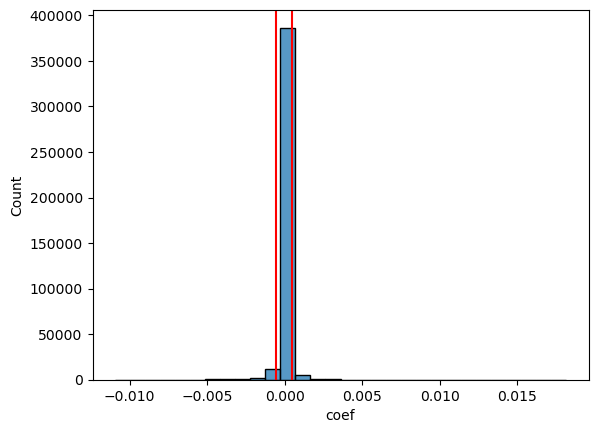

In [9]:
# plot distribution of coef values and draw lines at top 0.05 and bottom 0.05
sns.histplot(all_res_df["coef"], bins=30)
# get top 5% eprcentile value
top5_percentile = all_res_df["coef"].quantile(0.975)
bottom5_percentile = all_res_df["coef"].quantile(0.025)
plt.axvline(top5_percentile, color="red")
plt.axvline(bottom5_percentile, color="red")
print(top5_percentile, bottom5_percentile)
plt.show()

In [10]:
# Summarize significant RBPs by cell type and Outcome 
significant_rbps = all_res_df[
    (all_res_df["sig"] == "Yes") &
    (
        (all_res_df["coef"] > top5_percentile) | 
        (all_res_df["coef"] < bottom5_percentile)
    )
]
significant_rbps

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,0.002382,0.000677,0.0,0.001393,0.003275,Yes,EXOSC5,SP_2,Trachea_Epithelial,0.0,0.002382
1,Indirect,0.001601,0.000469,0.0,0.000865,0.001926,Yes,FASTKD2,SP_1,Trachea_Epithelial,0.0,0.001601
2,Indirect,0.001530,0.000502,0.0,0.000809,0.002112,Yes,SNRPA,SP_2,Trachea_Epithelial,0.0,0.001530
3,Indirect,-0.001527,0.000565,0.0,-0.002390,-0.000850,Yes,FASTKD2,SP_2,Trachea_Epithelial,0.0,0.001527
4,Indirect,0.001501,0.000497,0.0,0.000888,0.002359,Yes,CIRBP,SP_2,Trachea_Epithelial,0.0,0.001501
...,...,...,...,...,...,...,...,...,...,...,...,...
404060,Indirect,0.000458,0.000184,0.0,0.000175,0.000673,Yes,RALY,SP_4,Diaphragm_Endothelial,0.0,0.000458
404061,Indirect,0.000457,0.000257,0.0,0.000146,0.000924,Yes,RBFOX2,SP_2,Diaphragm_Endothelial,0.0,0.000457
404064,Indirect,0.000454,0.000198,0.0,0.000069,0.000567,Yes,WRN,SP_2,Diaphragm_Endothelial,0.0,0.000454
404065,Indirect,0.000452,0.000278,0.0,0.000149,0.000994,Yes,RRP9,SP_2,Diaphragm_Endothelial,0.0,0.000452


(76, 12)
 Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/rbp_aging_mediation_counts_heatmap_SUPPLEMENTARY.pdf


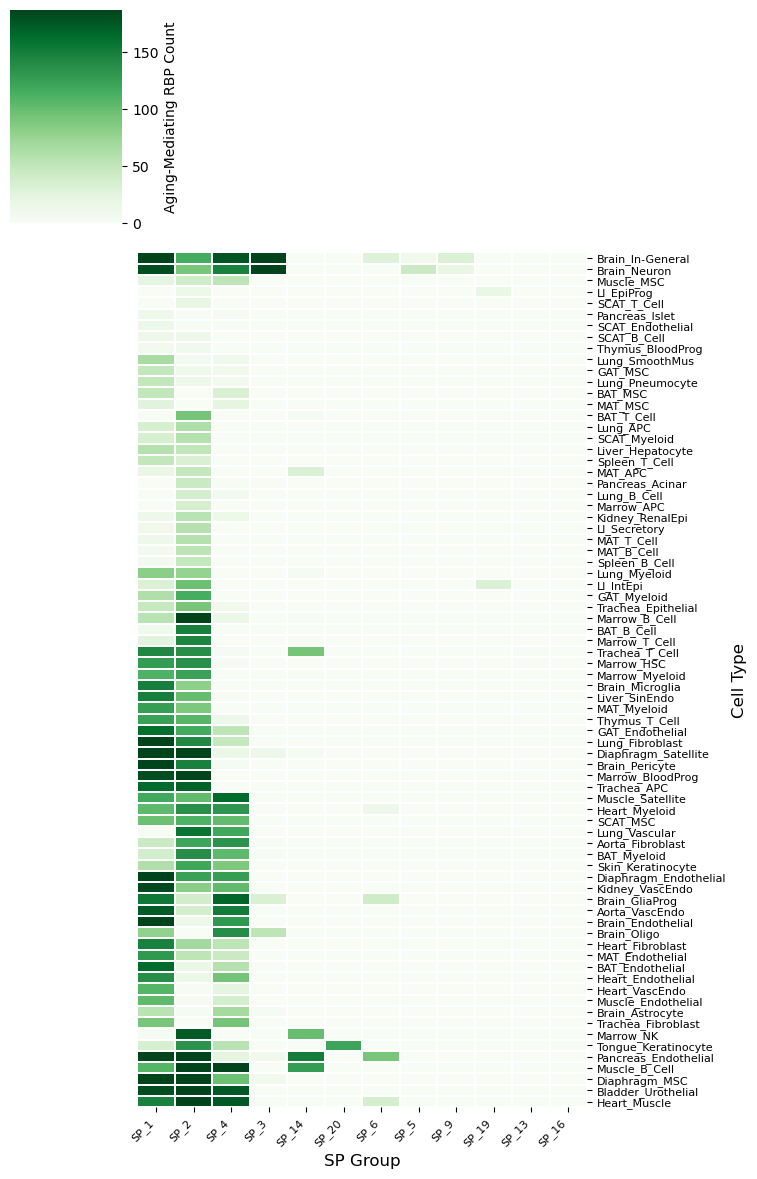

In [11]:
# Count how many RBPs are significant for each cell type and Outcome
rbp_counts = significant_rbps.groupby(["CellType", "Outcome"])["RBP"].count().reset_index()
rbp_counts_pivot = rbp_counts.pivot(index="CellType", columns="Outcome", values="RBP")
rbp_counts_pivot = rbp_counts_pivot.fillna(0)
print(rbp_counts_pivot.shape)

g = sns.clustermap(
    rbp_counts_pivot, 
    cmap="Greens", 
    linewidths=0.3,
    figsize=(8, 12),
    yticklabels=True,
    xticklabels=True,
    cbar_kws={"shrink":0.5, "label": "Aging-Mediating RBP Count"},
    robust=True
)

# Remove col/row cluster color bars for clean look
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel("SP Group", fontsize=12)
g.ax_heatmap.set_ylabel("Cell Type", fontsize=12)
plt.tight_layout()

plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=8)
plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=8, rotation=45, ha="right")
# Save the plot
plt.savefig(os.path.join(output_dir, "rbp_aging_mediation_counts_heatmap_SUPPLEMENTARY.pdf"), dpi=300, bbox_inches="tight")
print(f" Saved to {os.path.join(output_dir, 'rbp_aging_mediation_counts_heatmap_SUPPLEMENTARY.pdf')}")
plt.show()

In [12]:
significant_rbps.groupby(["Outcome", "RBP"])["CellType"].count()

Outcome  RBP   
SP_1     AATF      28
         ABCF1     20
         ABT1      26
         ACO1      34
         ADAR      17
                   ..
SP_9     SUCLG1     1
         SUGP2      1
         TUFM       1
         UCHL5      1
         YTHDC2     1
Name: CellType, Length: 1684, dtype: int64

In [13]:
def plot_ternary_density_faceted(
    splice_adata, 
    tern_keys=["SP_1", "SP_2", "SP_4"], 
    obs_key="age_numeric", 
    restrict_celltypes=None,
    use_regex=False,
    output_dir=None, 
    pdf_filename="ternary_density_faceted.pdf"
):
    """
    Generates publication-quality Ternary Density Plots (KDE) faceted by a metadata column (e.g., Age).
    Matches the style of the 'Structural Aging' figure.
    
    Parameters
    ----------
    splice_adata : AnnData object
    tern_keys : list, default ["SP_1", "SP_2", "SP_4"] (Left, Right, Top)
    obs_key : str, column to facet by (e.g., 'age_numeric')
    restrict_celltypes : list or str, filter for specific cells.
    use_regex : bool, if True, treats restrict_celltypes as a regex string.
    """
    
    # 1. Prepare Data
    obs = splice_adata.obs.copy()
    
    # Check keys exist
    for k in tern_keys + [obs_key]:
        if k not in obs.columns:
            raise KeyError(f"Key '{k}' not found in .obs")

    # Filter Cell Types
    if restrict_celltypes is not None:
        if "tissue_celltype" not in obs.columns:
            raise KeyError("'tissue_celltype' column missing.")
            
        if use_regex:
            # Filter using regex string (e.g., "Fibroblast|MSC")
            mask = obs["tissue_celltype"].str.contains(restrict_celltypes, case=False, regex=True, na=False)
            obs = obs[mask].copy()
            print(f"Filtered by Regex '{restrict_celltypes}'. Remaining cells: {len(obs)}")
        else:
            # Filter by exact list
            obs = obs[obs["tissue_celltype"].isin(restrict_celltypes)].copy()
            print(f"Filtered by list. Remaining cells: {len(obs)}")
            
        if obs.empty:
            print("No cells found after filtering! Exiting.")
            return

    # 2. Coordinate Transformation (Standard Equilateral)
    # tern_keys order: [Left (Aging A), Right (Aging B), Top (Youth)]
    a = obs[tern_keys[0]].values  # Left
    b = obs[tern_keys[1]].values  # Right
    c = obs[tern_keys[2]].values  # Top
    
    # Normalize rows to sum to 1
    total = a + b + c + 1e-9
    a_norm, b_norm, c_norm = a/total, b/total, c/total
    
    # Cartesian Mapping (Center at 0,0)
    # Top corner is (0, sqrt(3)/2), Left is (-0.5, 0), Right is (0.5, 0)
    x_all = 0.5 * (2 * b_norm + c_norm) / (a_norm + b_norm + c_norm) - 0.5
    y_all = (np.sqrt(3) / 2) * c_norm / (a_norm + b_norm + c_norm)
    
    # 3. Setup Facets
    unique_vals = np.sort(obs[obs_key].unique())
    n_groups = len(unique_vals)
    
    # Dynamic Figure Size
    fig, axes = plt.subplots(1, n_groups, figsize=(4.5 * n_groups, 5), sharex=True, sharey=True)
    if n_groups == 1: axes = [axes]
    
    # Triangle Geometry
    corners = np.array([[-0.5, 0], [0.5, 0], [0, np.sqrt(3)/2], [-0.5, 0]])
    
    # Color Palette (Distinct colors for each age/group)
    palette = sns.color_palette("viridis_r", n_colors=n_groups)

    # 4. Plotting Loop
    for i, (ax, group) in enumerate(zip(axes, unique_vals)):
        
        # A. Draw Triangle Border
        ax.plot(corners[:,0], corners[:,1], 'k-', lw=1.5, zorder=5)
        
        # B. Background Reference (All filtered cells in light grey)
        # This shows the "landscape" of possible states for this tissue type
        ax.scatter(x_all, y_all, c='#E0E0E0', s=1, alpha=0.15, rasterized=True, zorder=0)
        
        # C. Get Data for this Group
        mask_group = obs[obs_key] == group
        x_g = x_all[mask_group]
        y_g = y_all[mask_group]
        
        color = palette[i]
        
        # D. Density Plot (KDE) or Scatter fallback
        if len(x_g) > 10: # KDE fails if too few points
            try:
                sns.kdeplot(
                    x=x_g, y=y_g, 
                    fill=True, 
                    color=color, 
                    alpha=0.8, 
                    thresh=0.05,  # Hides the lowest 5% density (outliers)
                    levels=10, 
                    ax=ax, 
                    zorder=2
                )
                
                # E. "Center of Mass" Marker (The White X)
                mean_x, mean_y = np.mean(x_g), np.mean(y_g)
                ax.scatter(mean_x, mean_y, color='white', edgecolors='black', 
                           s=120, marker='X', lw=1.5, zorder=10, label='Mean')
                
            except Exception as e:
                print(f"KDE failed for {group}: {e}. Fallback to scatter.")
                ax.scatter(x_g, y_g, c=color, s=2, alpha=0.6)
        else:
            ax.scatter(x_g, y_g, c=color, s=5, alpha=0.8)
            
        # F. Labels and Styling
        # Title
        ax.set_title(f"{group} months\n(n={len(x_g)})", fontsize=14, fontweight='bold', color=color)
        ax.axis('off')
        ax.set_aspect('equal')
        
        # Corner Labels (Matches your SP names)
        # Top
        ax.text(0, np.sqrt(3)/2 + 0.04, f"Youth\n({tern_keys[2]})", ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#009E73')
        # Left
        ax.text(-0.55, -0.04, f"Aging A\n({tern_keys[0]})", ha='right', va='top', 
                fontsize=10, fontweight='bold', color='#D55E00')
        # Right
        ax.text(0.55, -0.04, f"Aging B\n({tern_keys[1]})", ha='left', va='top', 
                fontsize=10, fontweight='bold', color='#0072B2')

    plt.tight_layout()
    
    # 5. Save Output
    if output_dir is not None:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        # Clean up filename based on filters
        suffix = ""
        if restrict_celltypes is not None:
            clean_name = "multiple_celltypes"
            suffix = f"_filtered_{clean_name}"
            
        final_path = os.path.join(output_dir, pdf_filename.replace(".pdf", f"{suffix}.pdf"))
        plt.savefig(final_path, dpi=300, bbox_inches='tight')
        print(f"Saved figure to: {final_path}")
        
    plt.show()

Filtered by list. Remaining cells: 80557
Saved figure to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/ternary_density_faceted_filtered_multiple_celltypes.pdf


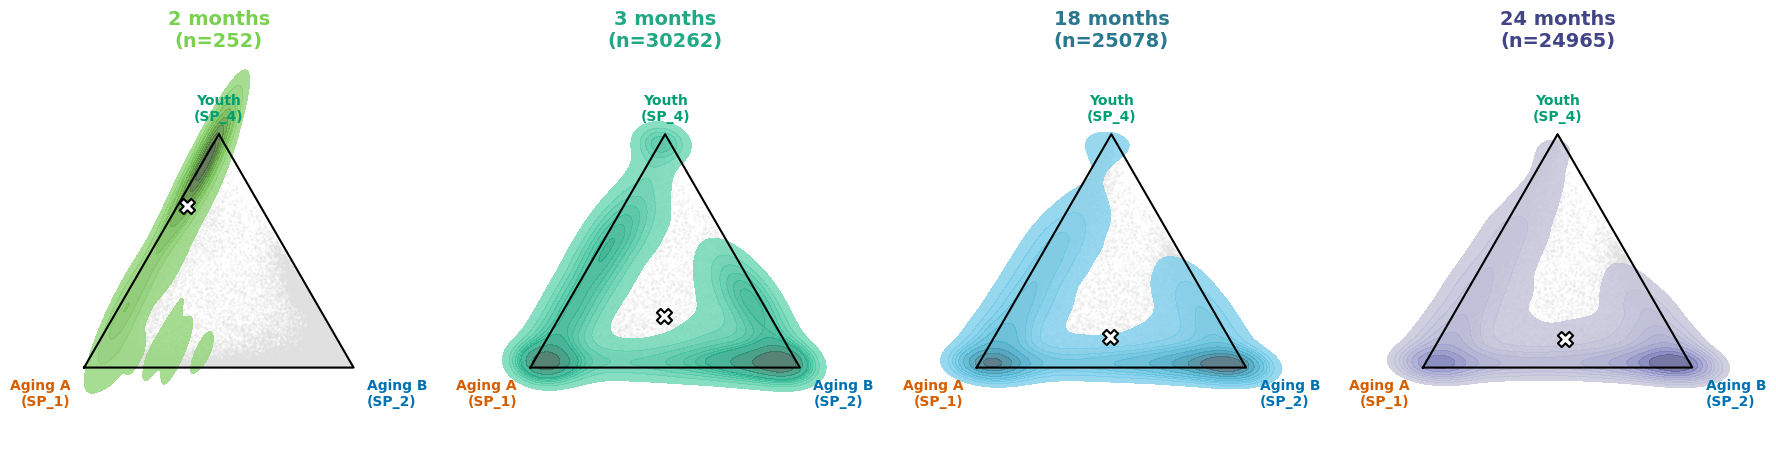

Saved figure to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/ternary_density_faceted.pdf


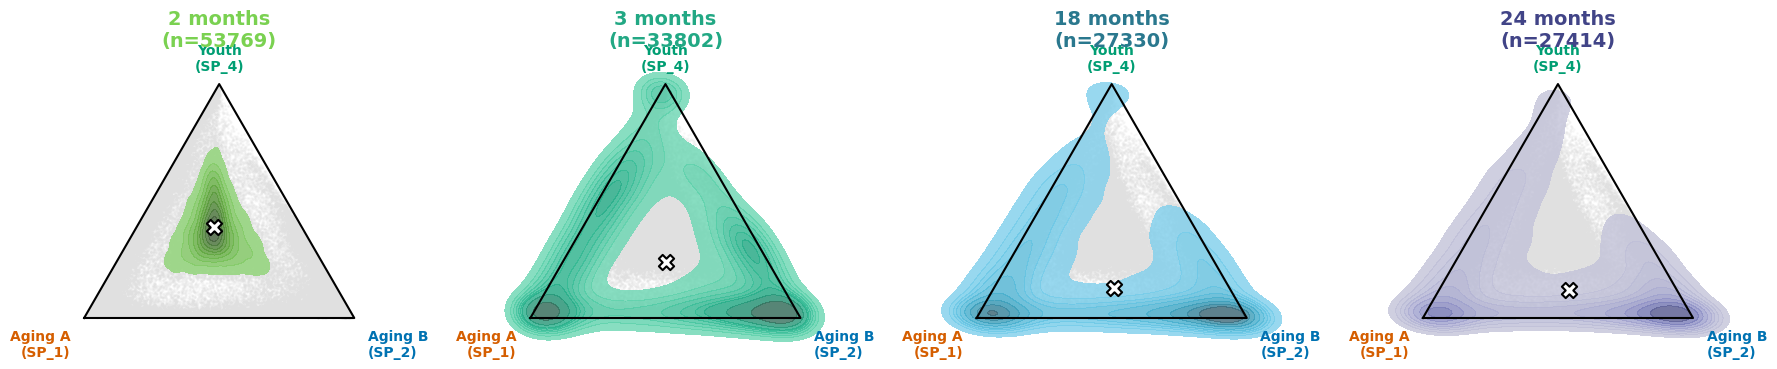

In [14]:
# Make a plot of the SP1/SP2/SP4 activity by age group (one filtered 76 cell types we studied in Figure 3)
plot_ternary_density_faceted(splice_adata, output_dir=output_dir, restrict_celltypes=significant_rbps["CellType"].unique())

# Make a plot of the SP1/SP2/SP4 activity by age group using ALL cell types
plot_ternary_density_faceted(splice_adata, output_dir=output_dir)

### Look into some of the 24m cells that are falling into SP4 high activity what is going on with them?

Saved RBP mediation heatmap to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/rbp_mediation_heatmap_n50.pdf


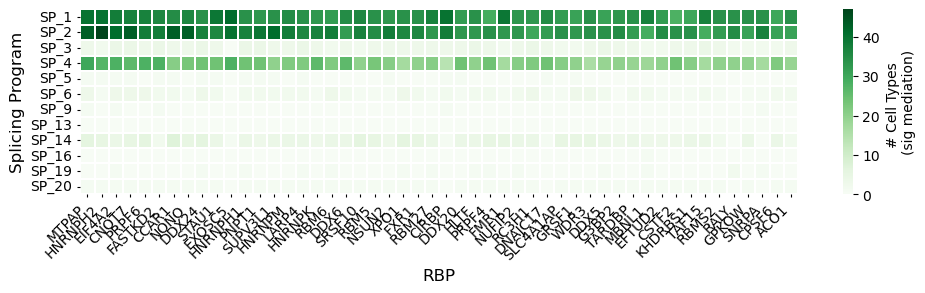

In [15]:
def plot_rbp_mediation_heatmap(significant_rbps, n_rbps=50, figsize=(10, 3), output_dir=None, pdf_filename="rbp_mediation_heatmap.pdf"):
    """
    Draws a heatmap for RBP mediation across splicing programs.
    RBPs on the x-axis, SPs on the y-axis.
    Each cell shows the number of cell types in which a given RBP mediates each SP (labels removed in this version).
    Uses a light pink-to-deep pink color gradient.
    
    Parameters:
    significant_rbps (pd.DataFrame): Must contain columns ['Outcome', 'RBP', 'CellType']
    n_rbps (int): Number of RBPs to include (default 60)
    figsize (tuple): Figure size for the heatmap (default (10,3))
    output_dir (str or None): If given, saves the plot as PDF to this directory
    pdf_filename (str): Name of the PDF file to save in output_dir
    """

    # Count how many cell types each RBP mediates for each SP
    # Format: Index=RBP, Columns=SP, Values=Count of CellTypes
    pivot_counts = (
        significant_rbps
        .groupby(["RBP", "Outcome"])["CellType"]
        .count()
        .unstack(fill_value=0)
    )

    # Sort RBPs by their total mediation activity, pick top n_rbps
    top_rbps = pivot_counts.sum(axis=1).sort_values(ascending=False).head(n_rbps).index
    plot_data = pivot_counts.loc[top_rbps]

    # Sort SP columns numerically
    sorted_sps = sorted(plot_data.columns, key=lambda x: int(x.split('_')[1]) if '_' in x else x)
    plot_data = plot_data.reindex(columns=sorted_sps)

    # Transpose to have SPs on y-axis, RBPs on x-axis
    plot_data = plot_data.T

    fig = plt.figure(figsize=figsize)

    # Plot WITHOUT annotations
    ax = sns.heatmap(
        plot_data,
        cmap="Greens",
        annot=False,
        linewidths=0.2,
        cbar_kws={'label': '# Cell Types \n(sig mediation)'},
        yticklabels=True,
        xticklabels=True,
        square=False
    )

    plt.ylabel("Splicing Program", fontsize=12)
    plt.xlabel("RBP", fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    ax.tick_params(axis='both', which='major', length=2, labelsize=10)

    # Save as PDF in output_dir if specified
    if output_dir is not None:
        import os
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        # Add n_rbps to pdf filename
        pdf_path = os.path.join(output_dir, pdf_filename.replace(".pdf", f"_n{n_rbps}.pdf"))
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f"Saved RBP mediation heatmap to: {pdf_path}")

    plt.show()

# Example usage with your dataframe:
plot_rbp_mediation_heatmap(significant_rbps, output_dir=output_dir)

In [16]:
# Lets subset significant RBPs to SP1 and SP2 
significant_rbps_sp1_sp2_sp4 = significant_rbps[significant_rbps["Outcome"].isin(["SP_1", "SP_2", "SP_4"])]
significant_rbps_sp1_sp2_sp4

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,0.002382,0.000677,0.0,0.001393,0.003275,Yes,EXOSC5,SP_2,Trachea_Epithelial,0.0,0.002382
1,Indirect,0.001601,0.000469,0.0,0.000865,0.001926,Yes,FASTKD2,SP_1,Trachea_Epithelial,0.0,0.001601
2,Indirect,0.001530,0.000502,0.0,0.000809,0.002112,Yes,SNRPA,SP_2,Trachea_Epithelial,0.0,0.001530
3,Indirect,-0.001527,0.000565,0.0,-0.002390,-0.000850,Yes,FASTKD2,SP_2,Trachea_Epithelial,0.0,0.001527
4,Indirect,0.001501,0.000497,0.0,0.000888,0.002359,Yes,CIRBP,SP_2,Trachea_Epithelial,0.0,0.001501
...,...,...,...,...,...,...,...,...,...,...,...,...
404060,Indirect,0.000458,0.000184,0.0,0.000175,0.000673,Yes,RALY,SP_4,Diaphragm_Endothelial,0.0,0.000458
404061,Indirect,0.000457,0.000257,0.0,0.000146,0.000924,Yes,RBFOX2,SP_2,Diaphragm_Endothelial,0.0,0.000457
404064,Indirect,0.000454,0.000198,0.0,0.000069,0.000567,Yes,WRN,SP_2,Diaphragm_Endothelial,0.0,0.000454
404065,Indirect,0.000452,0.000278,0.0,0.000149,0.000994,Yes,RRP9,SP_2,Diaphragm_Endothelial,0.0,0.000452


In [17]:
def print_mediation_stats(sig_rbps):
    # Filter for SP1, SP2, SP4
    subset = sig_rbps[sig_rbps["Outcome"].isin(["SP_1", "SP_2", "SP_4"])].copy()
    
    # 1. Total Unique RBPs
    total_rbps = subset['RBP'].nunique()
    print(f"Total Unique RBPs (X): {total_rbps}")
    
    # 2. Stats per Program
    for sp in ["SP_1", "SP_2", "SP_4"]:
        sp_data = subset[subset['Outcome'] == sp]
        n_interactions = len(sp_data)
        n_positive = len(sp_data[sp_data['coef'] > 0])
        pct_pos = (n_positive / n_interactions) * 100 if n_interactions > 0 else 0
        
        print(f"--- {sp} ---")
        print(f"  Interactions (Y): {n_interactions}")
        print(f"  % Positive (Activators) (Z): {pct_pos:.1f}%")
        print(f"  Unique RBPs: {sp_data['RBP'].nunique()}")

    # 3. Overlap (Jaccard)
    rbps_sp1 = set(subset[subset['Outcome'] == 'SP_1']['RBP'])
    rbps_sp2 = set(subset[subset['Outcome'] == 'SP_2']['RBP'])
    rbps_sp4 = set(subset[subset['Outcome'] == 'SP_4']['RBP'])
    
    # Intersection over Union (Jaccard) for SP1 vs SP2
    intersection = len(rbps_sp1 & rbps_sp2)
    union = len(rbps_sp1 | rbps_sp2)
    jaccard_1_2 = (intersection / union * 100) if union > 0 else 0
    
    # Overlap between Youth (SP4) and Aging (SP1 U SP2)
    aging_rbps = rbps_sp1 | rbps_sp2
    intersection_youth = len(rbps_sp4 & aging_rbps)
    union_youth = len(rbps_sp4 | aging_rbps)
    jaccard_youth = (intersection_youth / union_youth * 100) if union_youth > 0 else 0
    
    print(f"--- Overlaps ---")
    print(f"  SP1 vs SP2 Identity Overlap (P): {jaccard_1_2:.1f}%")
    print(f"  Youth (SP4) vs Aging (SP1/2) Overlap (Q): {jaccard_youth:.1f}%")

# Run it
print_mediation_stats(significant_rbps_sp1_sp2_sp4)

Total Unique RBPs (X): 269
--- SP_1 ---
  Interactions (Y): 6609
  % Positive (Activators) (Z): 45.2%
  Unique RBPs: 269
--- SP_2 ---
  Interactions (Y): 6350
  % Positive (Activators) (Z): 51.7%
  Unique RBPs: 269
--- SP_4 ---
  Interactions (Y): 3531
  % Positive (Activators) (Z): 41.3%
  Unique RBPs: 268
--- Overlaps ---
  SP1 vs SP2 Identity Overlap (P): 100.0%
  Youth (SP4) vs Aging (SP1/2) Overlap (Q): 99.6%


In [18]:
significant_rbps["sig"].value_counts()

sig
Yes    18076
Name: count, dtype: int64

In [19]:
significant_rbps

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,0.002382,0.000677,0.0,0.001393,0.003275,Yes,EXOSC5,SP_2,Trachea_Epithelial,0.0,0.002382
1,Indirect,0.001601,0.000469,0.0,0.000865,0.001926,Yes,FASTKD2,SP_1,Trachea_Epithelial,0.0,0.001601
2,Indirect,0.001530,0.000502,0.0,0.000809,0.002112,Yes,SNRPA,SP_2,Trachea_Epithelial,0.0,0.001530
3,Indirect,-0.001527,0.000565,0.0,-0.002390,-0.000850,Yes,FASTKD2,SP_2,Trachea_Epithelial,0.0,0.001527
4,Indirect,0.001501,0.000497,0.0,0.000888,0.002359,Yes,CIRBP,SP_2,Trachea_Epithelial,0.0,0.001501
...,...,...,...,...,...,...,...,...,...,...,...,...
404060,Indirect,0.000458,0.000184,0.0,0.000175,0.000673,Yes,RALY,SP_4,Diaphragm_Endothelial,0.0,0.000458
404061,Indirect,0.000457,0.000257,0.0,0.000146,0.000924,Yes,RBFOX2,SP_2,Diaphragm_Endothelial,0.0,0.000457
404064,Indirect,0.000454,0.000198,0.0,0.000069,0.000567,Yes,WRN,SP_2,Diaphragm_Endothelial,0.0,0.000454
404065,Indirect,0.000452,0.000278,0.0,0.000149,0.000994,Yes,RRP9,SP_2,Diaphragm_Endothelial,0.0,0.000452


In [20]:
def plot_top_discordant_rbps_mouse(res_df, target_sps=["SP_1", "SP_2", "SP_4"], top_n=20, output_dir=None):
    """
    Plots RBPs ranked by how strongly SP1/SP2 oppose SP4.
    
    Ranking Logic:
    Score = (Mean_SP1 + Mean_SP2) - Mean_SP4
    RBPs are selected by the highest Absolute Score.
    """
    
    # 1. Filter for Target SPs
    sig_df = res_df[res_df['Outcome'].isin(target_sps)].copy()
    
    if sig_df.empty:
        print("No significant mediators found.")
        return None

    # 2. Format Gene Names
    sig_df['RBP'] = sig_df['RBP'].astype(str).str.capitalize()

    # --- 3. NEW: Rank by "Discordance Score" (SP1+SP2 vs SP4) ---
    # Calculate the mean coefficient per SP for each RBP
    rbp_means = sig_df.groupby(['RBP', 'Outcome'])['coef'].mean().unstack(fill_value=0)
    
    # Ensure all columns exist (fill with 0 if an SP is missing entirely)
    for sp in target_sps:
        if sp not in rbp_means.columns:
            rbp_means[sp] = 0
            
    # Calculate the Score: (SP1 + SP2) - SP4
    # If SP1/2 are (+) and SP4 is (-), this is Positive.
    # If SP1/2 are (-) and SP4 is (+), this is Negative.
    rbp_means['Discordance_Score'] = (rbp_means['SP_1'] + rbp_means['SP_2']) - rbp_means['SP_4']
    
    # Sort by the MAGNITUDE (Absolute Value) of the discordance
    rbp_means['Abs_Score'] = rbp_means['Discordance_Score'].abs()
    ranked_rbps = rbp_means.sort_values('Abs_Score', ascending=False)
    
    # Select top N
    top_rbps = ranked_rbps.head(top_n).index.tolist()
    
    # Filter original data for plotting
    subset_plot = sig_df[sig_df['RBP'].isin(top_rbps)].copy()
    
    # Enforce sorted order for plotting (Top ranked RBP first)
    subset_plot['RBP'] = pd.Categorical(subset_plot['RBP'], categories=top_rbps, ordered=True)

    # 4. Plotting
    plt.figure(figsize=(12, 5)) # Slightly wider to accommodate labels
    sp_order = ["SP_1", "SP_2", "SP_4"]
    palette = {'SP_1': '#D55E00', 'SP_2': '#0072B2', 'SP_4': '#009E73'} 

    # Strip plot (individual points)
    sns.stripplot(
        data=subset_plot, x='RBP', y='coef', hue='Outcome', 
        hue_order=sp_order, dodge=True, alpha=0.4, size=3, jitter=0.2,
        palette=palette
    )

    # Box plot (distribution)
    sns.boxplot(
        data=subset_plot, x='RBP', y='coef', hue='Outcome', 
        hue_order=sp_order, dodge=True, showfliers=False, 
        palette=palette, boxprops={'alpha': 0.4}
    )

    plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    plt.ylabel("Aging Mediation Coefficient", fontsize=11)
    plt.xlabel("RBP Mediator (Ranked by SP1/2 vs SP4 Opposition)", fontsize=11)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    
    # Legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ordered_handles = [by_label[sp] for sp in sp_order if sp in by_label]
    ordered_labels = [sp for sp in sp_order if sp in by_label]
    plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.01, 1), loc='upper left', title='Splicing Program')
    
    plt.tight_layout()
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, f"Panel_D_{top_n}_RBP_Discordance.pdf")
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f"Plot saved to {out_path}")
    plt.show()

    # --- 5. Consistency Table (Updated) ---
    stats_list = []
    
    for rbp in top_rbps:
        # Get data for this specific RBP
        rbp_data = subset_plot[subset_plot['RBP'] == rbp]
        
        # Retrieve the score we calculated earlier for context
        score = rbp_means.loc[rbp, 'Discordance_Score']
        
        row = {
            'RBP': rbp,
            'Discordance_Score': round(score, 3) # Useful to see the magnitude
        }
        
        # Calculate counts
        for sp in sp_order:
            sp_data = rbp_data[rbp_data['Outcome'] == sp]
            n_pos = (sp_data['coef'] > 0).sum()
            n_neg = (sp_data['coef'] < 0).sum()
            
            row[f'{sp}_Pos'] = n_pos
            row[f'{sp}_Neg'] = n_neg
            
        stats_list.append(row)
        
    summary_df = pd.DataFrame(stats_list)
    return summary_df, ranked_rbps

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/Panel_D_30_RBP_Discordance.pdf


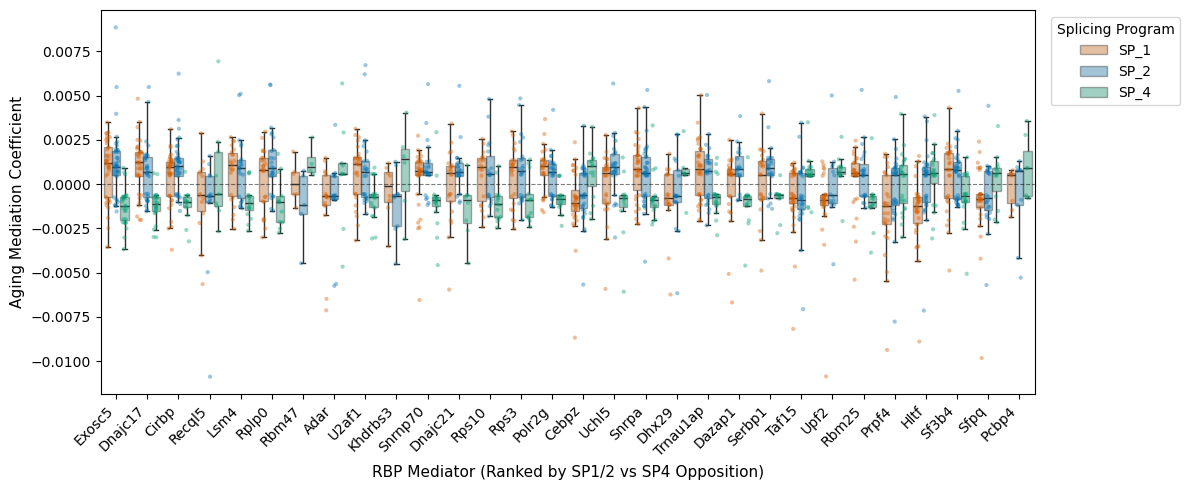

       RBP  Discordance_Score  SP_1_Pos  SP_1_Neg  SP_2_Pos  SP_2_Neg  \
0   Exosc5              0.003        30        11        32         8   
1  Dnajc17              0.003        27         8        21        11   
2    Cirbp              0.003        29        11        29         9   
3   Recql5             -0.003         6         8         4         9   
4     Lsm4              0.003        16         7        16         7   

   SP_4_Pos  SP_4_Neg  
0         3        25  
1         2        22  
2         1        13  
3         4         5  
4         3        13  


In [21]:
# --- HOW TO RUN AND INTERPRET ---
summary_df, ranked_rbps = plot_top_discordant_rbps_mouse(significant_rbps, top_n=30, output_dir=output_dir)
print(summary_df.head())

In [22]:
ranked_rbps

Outcome,SP_1,SP_2,SP_4,Discordance_Score,Abs_Score
RBP,,,,,
Exosc5,0.000898,0.001202,-0.001266,0.003366,0.003366
Dnajc17,0.001025,0.000697,-0.001210,0.002931,0.002931
Cirbp,0.000435,0.001026,-0.001155,0.002616,0.002616
Recql5,-0.000696,-0.001353,0.000508,-0.002557,0.002557
Lsm4,0.000657,0.000884,-0.000972,0.002512,0.002512
...,...,...,...,...,...
Hnrnpk,-0.000334,-0.000339,-0.000642,-0.000032,0.000032
Psip1,0.000117,-0.000258,-0.000169,0.000028,0.000028
Stau2,-0.000390,-0.000115,-0.000528,0.000023,0.000023


In [23]:
summary_df.sort_values(by="SP_4_Neg", ascending=False).iloc[0:20]

,RBP,Discordance_Score,SP_1_Pos,SP_1_Neg,SP_2_Pos,SP_2_Neg,SP_4_Pos,SP_4_Neg
0,Exosc5,0.003,30,11,32,8,3,25
1,Dnajc17,0.003,27,8,21,11,2,22
19,Trnau1ap,0.002,23,11,17,10,4,15
10,Snrnp70,0.002,25,7,17,5,2,15
27,Sf3b4,0.002,19,10,23,12,6,14
8,U2af1,0.002,19,8,15,10,4,14
17,Snrpa,0.002,25,9,25,12,3,14
2,Cirbp,0.003,29,11,29,9,1,13
20,Dazap1,0.002,20,8,15,4,1,13
4,Lsm4,0.003,16,7,16,7,3,13


Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/Panel_D_RBP_Quadrant.pdf


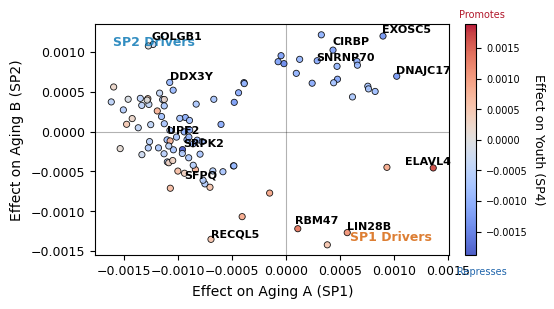

In [24]:
from adjustText import adjust_text

def plot_rbp_quadrant_publication(sig_rbps, top_n_plot=100, top_n_label=10, output_dir=None):
    """
    Refined Quadrant Plot for Panel D.
    - Plots top_n_plot dots (density).
    - Labels only top_n_label dots (clarity).
    - Square aspect ratio for scientific accuracy.
    """
    
    # 1. Data Prep
    pivot = sig_rbps.groupby(['RBP', 'Outcome'])['coef'].mean().unstack()
    for col in ['SP_1', 'SP_2', 'SP_4']:
        if col not in pivot.columns: pivot[col] = 0
    pivot = pivot.fillna(0)
    
    # Calculate magnitude to find the "Drivers"
    pivot['magnitude'] = pivot['SP_1'].abs() + pivot['SP_2'].abs() + pivot['SP_4'].abs()
    
    # Filter: Get the cloud of points to plot
    plot_data = pivot.nlargest(top_n_plot, 'magnitude')
    
    # Filter: Get the specific points to LABEL (The most extreme ones)
    label_data = pivot.nlargest(top_n_label, 'magnitude')
    
    # Explicitly ensure Key Drivers are labeled if they are in the top_n_plot list
    # (Optional: Add specific genes you definitely want to see)
    must_show = ['EXOSC5', 'SNRNP70', "DNAJC17", "CIRBP", "UPF2", "SFPQ"]
    for gene in must_show:
        if gene in plot_data.index and gene not in label_data.index:
            label_data = pd.concat([label_data, plot_data.loc[[gene]]])

    # 2. Setup Figure (Square is best for X vs Y comparison)
    fig, ax = plt.subplots(figsize=(5,3)) 

    # 3. Crosshairs
    ax.axhline(0, color='black', lw=0.8, alpha=0.3, zorder=0)
    ax.axvline(0, color='black', lw=0.8, alpha=0.3, zorder=0)
    ax.grid(False) # Turn off grid for cleaner look

    # 4. Scatter Plot
    # Center the colormap at 0
    vabs = max(abs(plot_data['SP_4']))
    
    sc = ax.scatter(
        plot_data['SP_1'], plot_data['SP_2'],
        c=plot_data['SP_4'],
        cmap='coolwarm',
        s=20, 
        edgecolors='black', 
        linewidth=0.6,
        alpha=0.9,
        vmin=-vabs, vmax=vabs,
        zorder=2
    )

    # 5. Smart Labeling
    texts = []
    for idx, row in label_data.iterrows():
        texts.append(ax.text(row['SP_1'], row['SP_2'], idx, fontsize=8, fontweight='bold', zorder=5))
    
    # Adjust text to avoid overlaps
    try:
        adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    except ImportError:
        pass

    # 6. Quadrant Annotations (Compact)
    # Bottom Right
    ax.text(0.95, 0.05, "SP1 Drivers", transform=ax.transAxes, 
            ha='right', va='bottom', color='#D55E00', fontweight='bold', fontsize=9, alpha=0.8)
    # Top Left
    ax.text(0.05, 0.95, "SP2 Drivers", transform=ax.transAxes, 
            ha='left', va='top', color='#0072B2', fontweight='bold', fontsize=9, alpha=0.8)

    # 7. Axes Labels and Ticks
    ax.set_xlabel("Effect on Aging A (SP1)", fontsize=10, labelpad=5)
    ax.set_ylabel("Effect on Aging B (SP2)", fontsize=10, labelpad=5)
    ax.tick_params(labelsize=9)

    # 8. Colorbar (Inset or Compact Side)
    # Side bar looks cleaner for publication
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Effect on Youth (SP4)', rotation=270, labelpad=12, fontsize=9)
    cbar.ax.tick_params(labelsize=7)
    # Add a visual helper on the colorbar
    cbar.ax.text(1.5, 1.02, 'Promotes', transform=cbar.ax.transAxes, ha='center', va='bottom', fontsize=7, color='#b2182b')
    cbar.ax.text(1.5, -0.05, 'Represses', transform=cbar.ax.transAxes, ha='center', va='top', fontsize=7, color='#2166ac')

    # 9. Save
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        out_path = os.path.join(output_dir, "Panel_D_RBP_Quadrant.pdf")
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
        print(f"Saved to {out_path}")
        
    plt.show()

# Run it
plot_rbp_quadrant_publication(significant_rbps_sp1_sp2_sp4, output_dir=output_dir)

Saved SNRNP70 distribution figure to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/Panel_D_SNRNP70_Boxplot.pdf


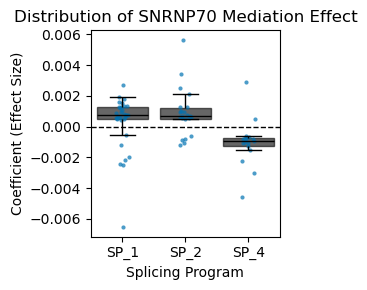

In [25]:
# Show distribution of ADAR coef values by Outcome (SP) as a jitterplot with boxplot overlay
gene_viz = "SNRNP70"
gene_viz_df = significant_rbps_sp1_sp2_sp4[significant_rbps_sp1_sp2_sp4["RBP"] == gene_viz]

# Explicitly set category order for x axis (Outcome)
order = ["SP_1", "SP_2", "SP_4"]

fig, ax = plt.subplots(figsize=(3,3))

sns.stripplot(
    x="Outcome", y="coef", data=gene_viz_df, 
    order=order,
    jitter=True, 
    size=3, 
    color="#0072B2", 
    alpha=0.7, 
    zorder=2,
    ax=ax
)

sns.boxplot(
    x="Outcome", y="coef", data=gene_viz_df, 
    order=order,
    whis=1.5, showfliers=False, 
    boxprops=dict(alpha=.6, zorder=1), 
    linewidth=1, 
    color="black",
    ax=ax
)

ax.axhline(0, color='k', linestyle='--', linewidth=1, zorder=0)
ax.set_title("Distribution of " + gene_viz + " Mediation Effect")
ax.set_ylabel("Coefficient (Effect Size)")
ax.set_xlabel("Splicing Program")
plt.tight_layout()

# Save as PDF to the output_dir, if defined
if 'output_dir' in globals() and output_dir is not None:
    os.makedirs(output_dir, exist_ok=True)
    pdf_path = os.path.join(output_dir, f"Panel_D_{gene_viz}_Boxplot.pdf")
    plt.savefig(pdf_path, bbox_inches="tight", dpi=300)
    print(f"Saved {gene_viz} distribution figure to {pdf_path}")

plt.show()

In [26]:
ge_adata.layers["scVI_normalized"] = ge_adata.obsm["X_normalized_scVI_linear"]

In [27]:
def plot_panel_E_with_validation(
    ge_adata, splice_adata, 
    rbp_gene="SNRNP70", 
    cell_types=None,
    age_col="age_numeric",
    output_dir=None,
    filename="Panel_E_Mechanism_Validation.pdf"
):
    """
    Generates:
    1. RBP Expression vs Age (Boxplot)
    2. Splicing Program Activity vs Age (Boxplot)
    3. (Validation) Scatter: RBP vs SP4 Activity with per-age regression lines.
    Removes outlier numbers in the RBP expression by filtering beyond 1.5*IQR.
    """

    # --- 1. ROBUST DATA EXTRACTION ---
    if cell_types is None:
        print("Error: Please provide `cell_types`.")
        return
    if isinstance(cell_types, str):
        cell_types = [cell_types]

    # Align indices
    ct_mask = splice_adata.obs['tissue_celltype'].isin(cell_types)
    cells = splice_adata.obs[ct_mask].index.intersection(ge_adata.obs_names)
    
    if len(cells) < 10:
        print(f"Not enough cells found for {cell_types}.")
        return

    # Extract Gene Expression
    try:
        if "scVI_normalized" in ge_adata.layers:
            data_src = ge_adata[cells, rbp_gene].layers["scVI_normalized"]
        else:
            data_src = ge_adata[cells, rbp_gene].X 
            
        if scipy.sparse.issparse(data_src):
            expr = data_src.toarray().flatten()
        else:
            expr = data_src.flatten()
    except KeyError:
        print(f"Gene {rbp_gene} not found.")
        return

    # --- DATA FRAME PREP ---
    raw_ages = splice_adata.obs.loc[cells, age_col]
    
    df = pd.DataFrame({
        'Age_Numeric': pd.to_numeric(raw_ages, errors='coerce'),
        'RBP_Expression': expr,
        'SP1': splice_adata.obs.loc[cells, 'SP_1'],
        'SP2': splice_adata.obs.loc[cells, 'SP_2'],
        'SP4': splice_adata.obs.loc[cells, 'SP_4'],
        'CellType': splice_adata.obs.loc[cells, 'tissue_celltype'].astype(str)
    }).dropna(subset=['Age_Numeric'])
    
    # Remove outliers in RBP_Expression using the 1.5*IQR rule
    q1 = df['RBP_Expression'].quantile(0.25)
    q3 = df['RBP_Expression'].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df['RBP_Expression'] >= lower) & (df['RBP_Expression'] <= upper)]
    
    # Sort ages numerically for consistent coloring
    sorted_unique_ages = sorted(df['Age_Numeric'].unique())
    # Create string labels like "3", "18"
    df['Age_Label'] = df['Age_Numeric'].astype(str).replace('\.0', '', regex=True)
    age_order = [str(x).replace('.0','') for x in sorted_unique_ages]

    # Melt for SP plot
    sp_df = df.melt(
        id_vars=['Age_Label', 'CellType'],
        value_vars=['SP1', 'SP2', 'SP4'],
        var_name='SplicingProgram', value_name='SP_Activity'
    )

    # --- 2. PLOTTING ---
    sns.set_context("paper", font_scale=1.1)
    sns.set_style("ticks")
    
    # Custom Palette
    base_colors = ['#66c2a5', '#fc8d62', '#8da0cb'] # Teal, Orange, Purple
    # Map colors to age labels safely
    palette_dict = {age: color for age, color in zip(age_order, base_colors)}
    
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), gridspec_kw={'width_ratios': [1, 1, 1]})

    # [PLOT 1] RBP Expression
    sns.boxplot(
        data=df, x='CellType', y='RBP_Expression', hue='Age_Label', 
        ax=axes[0], palette=palette_dict, showfliers=False, 
        hue_order=age_order
    )
    axes[0].set_title(f"Mechanism: {rbp_gene} Increase")
    axes[0].set_xlabel("")
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(title='Age (m)', frameon=False)

    # [PLOT 2] Splicing Activity
    sns.boxplot(
        data=sp_df, x='SplicingProgram', y='SP_Activity', hue='Age_Label', 
        ax=axes[1], palette=palette_dict, showfliers=False,
        hue_order=age_order
    )
    axes[1].set_title("Consequence: Splicing Change")
    axes[1].set_xlabel("")
    axes[1].get_legend().remove()

    # [PLOT 3] The "Validation" Scatter with Per-Group Lines
    # 1. Plot the points first
    sns.scatterplot(
        data=df, x='RBP_Expression', y='SP4', hue='Age_Label',
        ax=axes[2], palette=palette_dict, s=15, alpha=0.5,
        hue_order=age_order, edgecolor=None, legend=False
    )
    
    # 2. Loop to add a regression line for EACH age group
    # This proves the correlation exists *within* the group, not just between them.
    for age in age_order:
        subset = df[df['Age_Label'] == age]
        if len(subset) > 5: # Only plot line if enough points
            sns.regplot(
                data=subset, x='RBP_Expression', y='SP4', 
                ax=axes[2], scatter=False, 
                color=palette_dict[age], truncate=True, ci=None
            )
    
    # Calculate Global Correlation for the title
    corr = df[['RBP_Expression', 'SP4']].corr().iloc[0,1]
    axes[2].set_title(f"Overall Correlation (r={corr:.2f})")
    axes[2].set_xlabel(f"{rbp_gene} Expression")
    axes[2].set_ylabel("Youth Program (SP4) Score")
    
    # 3. FORCE Y-AXIS TO BE POSITIVE
    # This hides any part of the regression line that dips below 0
    axes[2].set_ylim(bottom=0, top=1.05) 

    sns.despine()
    plt.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
        print(f"Saved to {os.path.join(output_dir, filename)}")
        
    plt.show()

In [28]:
gene_sig_df = significant_rbps_sp1_sp2_sp4[significant_rbps_sp1_sp2_sp4["RBP"] == "SNRNP70"]
# Which cell types in gene_sig_df have positive SP_1 or SP_2 AND negative SP_4?
# Find cell types where SNRNP70 shows positive effect in SP_1 or SP_2 and negative in SP_4
pivot = gene_sig_df.pivot(index="CellType", columns="Outcome", values="coef")
cell_types = pivot[(pivot.get("SP_1", 0) > 0) | (pivot.get("SP_2", 0) > 0)]
cell_types = cell_types[cell_types.get("SP_4", 0) < 0]
cell_types.sort_values(by="SP_4", ascending=True)

Outcome,SP_1,SP_2,SP_4
CellType,,,
Bladder_Urothelial,-0.002494,0.005649,-0.003029
BAT_MSC,0.002738,NaN,-0.002210
Muscle_B_Cell,-0.001163,0.003450,-0.001546
Skin_Keratinocyte,NaN,0.002105,-0.001256
Heart_Endothelial,0.001284,NaN,-0.001061
MAT_MSC,0.001111,NaN,-0.000982
Heart_Muscle,NaN,0.001301,-0.000915
Trachea_Fibroblast,0.001215,NaN,-0.000835
Brain_Endothelial,0.001918,NaN,-0.000826


In [29]:
# The list above includes primary cell types known to accumulate Cellular Senescence and drive "Inflammaging" (chronic, low-grade inflammation) via the Senescence-Associated Secretory Phenotype (SASP).
# The SASP Connection: Fibroblasts, Endothelial cells, and Keratinocytes are the major producers of SASP factors (cytokines, proteases) in aged tissue. Producing these factors requires massive transcriptional upregulation.
# U1 snRNP (SNRNP70) Demand: SNRNP70 is a core component of the U1 snRNP (part of the spliceosome). 
# * Hypothesis: As these cells become senescent and ramp up transcription (to pump out SASP or repair damage), they may overexpress SNRNP70 to cope with the splicing load.
# Consequence: High levels of U1-70K (SNRNP70) can alter 5' splice site selection, potentially repressing the "Youth Splicing Program" (SP4).

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/Panel_E_Mechanism_Validation.pdf


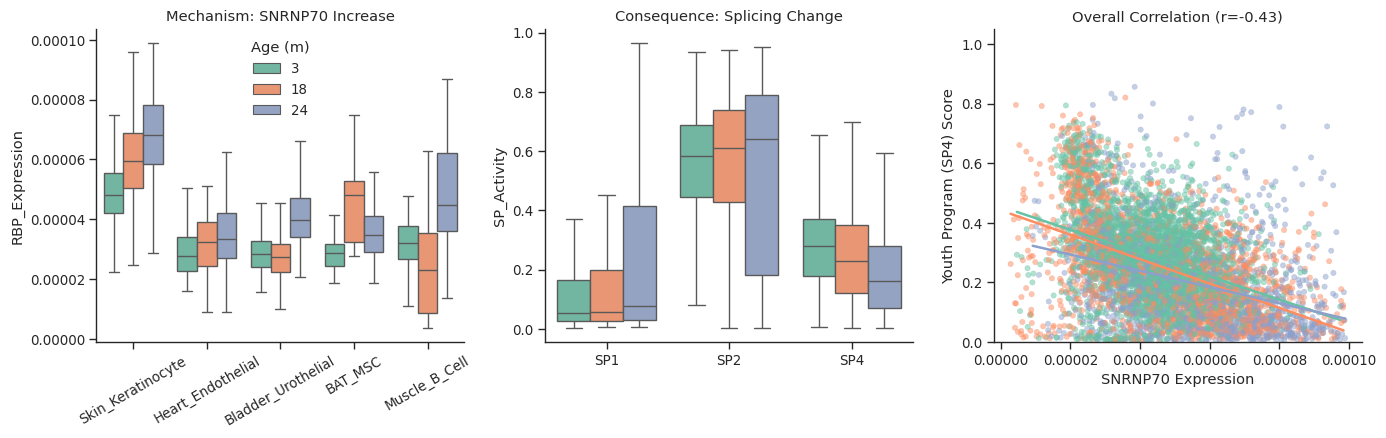

In [30]:
# Example Usage
plot_panel_E_with_validation(ge_adata, splice_adata, rbp_gene="SNRNP70", cell_types=['Bladder_Urothelial', 'BAT_MSC', 'Muscle_B_Cell', 'Skin_Keratinocyte', 'Heart_Endothelial'], output_dir=output_dir)

In [31]:
# Core SASP and Senescence markers
sasp_genes = [
    'CDKN2A', 'CDKN1A',          # Cycle Arrest (p16, p21)
    'IL6', 'IL1B', 'TNF',        # Inflammatory Cytokines
    'CCL2', 'CXCL1', 'CXCL2',    # Chemokines
    'MMP3', 'MMP12', 'PLAU',     # Matrix Remodeling (common in stroma)
    'ICAM1', 'FAS'               # Surface markers
]

# Calculate SASP score for each cell via ge_adata by averaging expression of SASP genes
sasp_present = [g for g in sasp_genes if g in ge_adata.var_names]
print(sasp_present) # ['CDKN1A', 'IL1B', 'CXCL1', 'PLAU', 'ICAM1', 'FAS'] 
print(f"Using {len(sasp_present)}/{len(sasp_genes)} SASP genes found in data.")

# Make sure X in ge_adata is the scVI normalized data
ge_adata.X = ge_adata.obsm["X_normalized_scVI_linear"]
sc.tl.score_genes(ge_adata, gene_list=sasp_present, score_name='SASP_Score')

['CDKN1A', 'IL1B', 'CXCL1', 'PLAU', 'ICAM1', 'FAS']
Using 6/13 SASP genes found in data.


In [32]:
ge_adata.obs["SP_4"] = splice_adata.obs["SP_4"]

<Axes: xlabel='SASP_Score', ylabel='SP_4'>

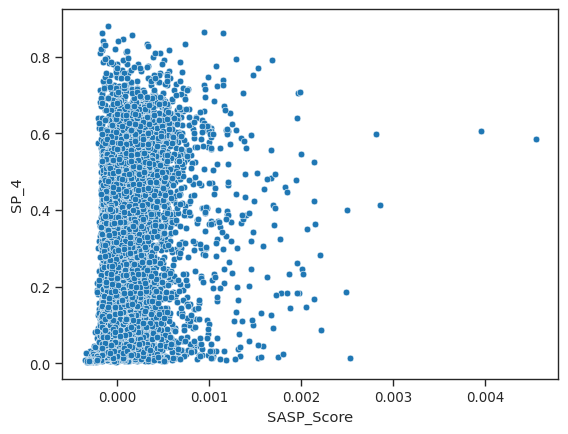

In [33]:
# Correlate SP4 vs SASP_Score
# Correlate SP4 vs SASP_Score, but only for cell types in cell_types
sns.scatterplot(data=ge_adata.obs[ge_adata.obs["tissue_celltype"].isin(cell_types.index)], x="SASP_Score", y="SP_4")

In [34]:
splice_adata.var[splice_adata.var["gene_name"] == "SNRNP70"]

,index,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,junction_id_index,n_cells_detected,confidence,aging_gene,aging_lifespan_effect,aging_longevity_influence,RBP_gene,Aging_gene
75242,95659,chr7_45380818_45383124_-,ENSMUSG00000063511.11_atse_2,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,31127,58784,1829,high,False,NaN,NaN,True,False
75243,95660,chr7_45380818_45383803_-,ENSMUSG00000063511.11_atse_2,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,1011417,58785,51788,high,False,NaN,NaN,True,False
75244,95661,chr7_45383184_45383803_-,ENSMUSG00000063511.11_atse_2,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,105384,58786,16510,high,False,NaN,NaN,True,False
75245,95662,chr7_45394815_45395092_-,ENSMUSG00000063511.11_atse_1,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,88419,58787,7055,high,False,NaN,NaN,True,False
75246,95663,chr7_45394815_45395508_-,ENSMUSG00000063511.11_atse_1,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,675982,58788,58632,high,False,NaN,NaN,True,False
75247,95664,chr7_45395172_45395508_-,ENSMUSG00000063511.11_atse_1,GT-AG,both,SNRNP70,ENSMUSG00000063511,3,1.0,0.0,52201,58789,5348,high,False,NaN,NaN,True,False


In [35]:
pivot_counts = (
        significant_rbps
        .groupby(["RBP", "Outcome"])["CellType"]
        .count()
        .unstack(fill_value=0)
    )

# Sort RBPs by their total mediation activity, pick top n_rbps
top_rbps = pivot_counts.sum(axis=1).sort_values(ascending=False)
top_rbps

RBP
MTPAP      128
HNRNPH2    124
EIF4A2     122
CNOT7      120
PRPF6      116
          ... 
NUSAP1      14
KHDRBS2     14
IGF2BP2     14
ELAVL4       7
RBM24        6
Length: 269, dtype: int64

Collinearity plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/rbp_collinearity.pdf


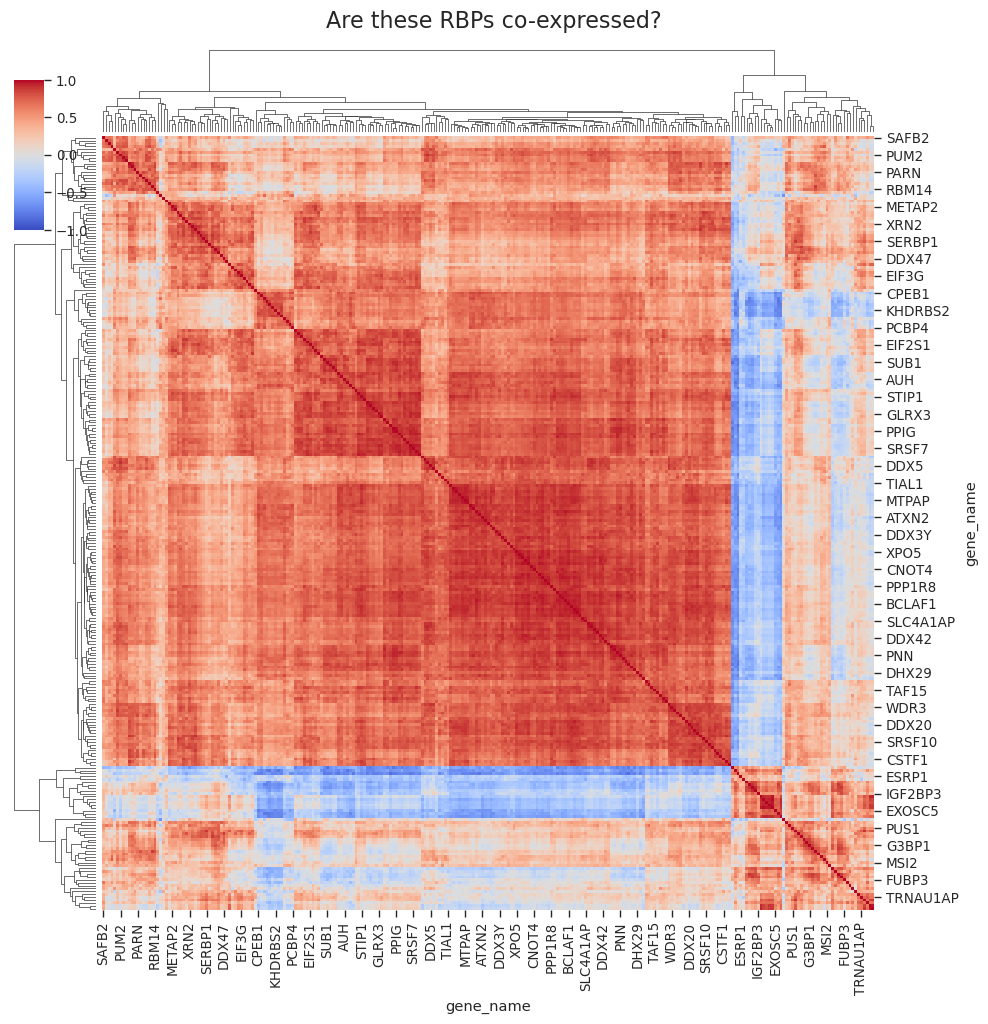

In [36]:
def check_rbp_collinearity(ge_adata, top_rbps_list, output_dir=None, pdf_filename="rbp_collinearity.pdf"):
    """
    Checks if the 'Top RBPs' are just highly correlated copies of each other.
    Optionally saves the cluster map to PDF in the specified output_dir.
    """
    import os

    # 1. Subset data to just these RBPs
    valid_rbps = [g for g in top_rbps_list if g in ge_adata.var_names]
    
    if not valid_rbps:
        print("RBPs not found in gene list.")
        return

    # 2. Get Expression Data
    rbp_exp = ge_adata[:, valid_rbps].to_df()
    
    # 3. Calculate Correlation
    corr_matrix = rbp_exp.corr(method='spearman')
    
    # 4. Cluster and Plot
    g = sns.clustermap(
        corr_matrix, 
        cmap='coolwarm', 
        center=0, 
        vmin=-1, vmax=1,
        figsize=(10, 10),
        annot=False,
        dendrogram_ratio=(0.1, 0.1),
        cbar_pos=(0.02, 0.8, 0.03, 0.15)
    )
    g.fig.suptitle("Are these RBPs co-expressed?", y=1.02, fontsize=16)

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        pdf_path = os.path.join(output_dir, pdf_filename)
        g.fig.savefig(pdf_path, bbox_inches='tight', dpi=300)
        print(f"Collinearity plot saved to {pdf_path}")
    else:
        plt.show()

# Example usage:
# Provide output_dir to save as PDF, otherwise shows interactively
check_rbp_collinearity(ge_adata, top_rbps.index, output_dir=output_dir)

Saved ternary plot PDF to: /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/ternary_per_mouse_TMS.pdf


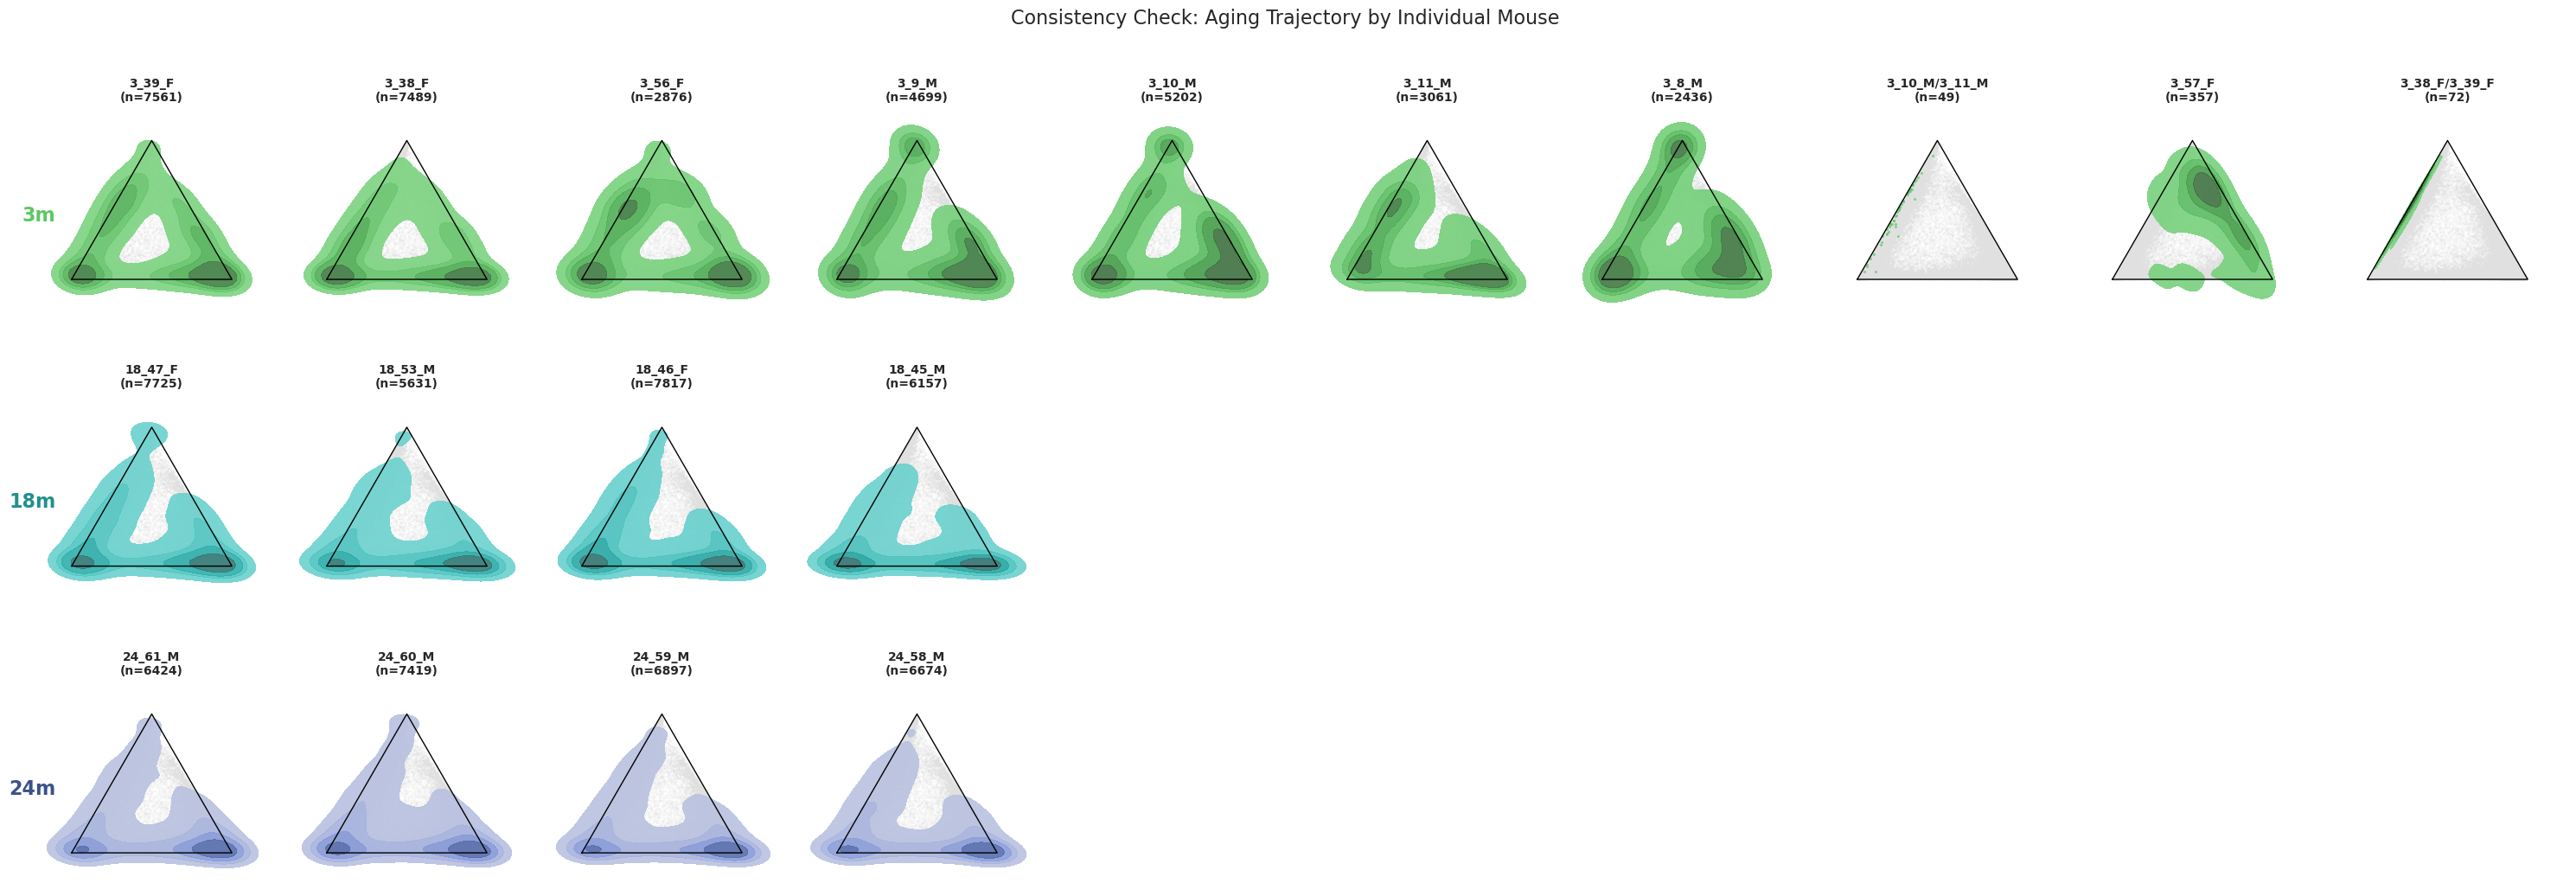

In [37]:
def plot_ternary_per_mouse(
    splice_adata, 
    subset_col="dataset", 
    keep_only_subset="TMS",  # if None then all mice are plotted
    batch_key='donor_id',  
    age_col='age_numeric',
    output_dir=None          # Directory to save PDF, if provided
):
    """
    Plots a ternary density for EVERY individual mouse to demonstrate robustness. 
    Each subplot is a mouse, arranged by age (rows) and mouse (columns).
    If keep_only_subset is set, only cells where subset_col==keep_only_subset will be used.
    Always saves the plot as PDF in output_dir, prefixing filename with the subset if given.
    """

    # Optionally subset to only the specified dataset
    if keep_only_subset is not None:
        cells_mask = splice_adata.obs[subset_col] == keep_only_subset
        data_obs = splice_adata.obs[cells_mask].copy()
        subset_label = str(keep_only_subset)
    else:
        data_obs = splice_adata.obs.copy()
        subset_label = "allmice"

    # Get coordinate data for ternary plot (SP_1, SP_2, SP_4 are required)
    a = data_obs['SP_1'].values
    b = data_obs['SP_2'].values
    c = data_obs['SP_4'].values
    total = a + b + c + 1e-9

    # Compute ternary (X, Y) coordinates
    tx = 0.5 * (2 * (b/total) + (c/total)) / ((a/total) + (b/total) + (c/total)) - 0.5
    ty = (np.sqrt(3) / 2) * (c/total) / ((a/total) + (b/total) + (c/total))
    data_obs['tx'] = tx
    data_obs['ty'] = ty

    # Group mice by age, ignoring age==2 if present
    ages = np.sort(data_obs[age_col].unique())
    ages = [x for x in ages if x != 2]
    mouse_groups = {}
    max_mice = 0
    for age in ages:
        group = data_obs[data_obs[age_col] == age][batch_key].unique()
        mouse_groups[age] = group
        if len(group) > max_mice:
            max_mice = len(group)

    fig, axes = plt.subplots(len(ages), max_mice, figsize=(3 * max_mice, 3.5 * len(ages)), 
                             sharex=True, sharey=True)

    # handle axes shape for one row or one column
    if len(ages) == 1 and max_mice == 1:
        axes = np.array([[axes]])
    elif len(ages) == 1:
        axes = axes.reshape(1, -1)
    elif max_mice == 1:
        axes = axes.reshape(-1, 1)

    corners = np.array([[-0.5, 0], [0.5, 0], [0, np.sqrt(3)/2], [-0.5, 0]])
    palette = sns.color_palette("viridis_r", n_colors=len(ages))

    # Plot, each subplot: a mouse
    for row_idx, age in enumerate(ages):
        mice = mouse_groups[age]
        color = palette[row_idx]
        for col_idx in range(max_mice):
            ax = axes[row_idx, col_idx]
            # Draw triangle border
            ax.plot(corners[:, 0], corners[:, 1], 'k-', lw=1, zorder=5)
            ax.axis('off')
            ax.set_aspect('equal')
            if col_idx < len(mice):
                mouse = mice[col_idx]
                mouse_data = data_obs[data_obs[batch_key] == mouse]
                # Plot gray reference: all cells from all mice in this group
                ax.scatter(data_obs['tx'], data_obs['ty'], c='#E0E0E0', s=1, alpha=0.08, rasterized=True, zorder=0)
                # Plot specific mouse
                if len(mouse_data) > 50:
                    try:
                        sns.kdeplot(
                            x=mouse_data['tx'], y=mouse_data['ty'],
                            fill=True, color=color, alpha=0.9,
                            thresh=0.05, levels=5, ax=ax, zorder=2
                        )
                    except Exception:
                        ax.scatter(mouse_data['tx'], mouse_data['ty'], c=[color], s=2, alpha=0.6)
                else:
                    ax.scatter(mouse_data['tx'], mouse_data['ty'], c=[color], s=2, alpha=0.6)
                ax.set_title(f"{mouse}\n(n={len(mouse_data)})", fontsize=10, fontweight='bold')
                # Age label only on first column
                if col_idx == 0:
                    ax.text(-0.6, 0.4, f"{age}m", fontsize=16, fontweight='bold', va='center', ha='right', color=color)
            else:
                ax.set_visible(False)

    plt.suptitle("Consistency Check: Aging Trajectory by Individual Mouse", y=1.02, fontsize=16)
    plt.tight_layout()
    # ALWAYS save as PDF in output_dir if provided
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        fname = f"ternary_per_mouse_{subset_label}.pdf"
        outpath = os.path.join(output_dir, fname)
        plt.savefig(outpath, bbox_inches='tight')
        print(f"Saved ternary plot PDF to: {outpath}")
    plt.show()

# Usage example: Always saves as PDF in output_dir.
# plot_ternary_per_mouse(splice_adata, batch_key='donor_id', output_dir='pdf_output')
plot_ternary_per_mouse(splice_adata, batch_key='donor_id', output_dir=output_dir)

In [38]:
splice_adata.layers["denoised_PSI"] = splice_adata.obsm["X_PHI"] @ splice_adata.varm["psi_learned"].T
splice_adata

AnnData object with n_obs × n_vars = 142315 × 70102
    obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
    var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_influ

In [39]:
# Summarize how many SPs had at least 1 significant RBP across at least two cell types
significant_rbps_counts = significant_rbps.groupby(["Outcome", "RBP"])["CellType"].count().reset_index()
significant_rbps_counts = significant_rbps_counts[significant_rbps_counts["CellType"] > 1]
significant_rbps_counts["Outcome"].value_counts()

Outcome
SP_1     269
SP_2     268
SP_4     267
SP_3     217
SP_14    133
SP_6      53
SP_19      4
Name: count, dtype: int64

In [40]:
all_res_df

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,2.382016e-03,6.768175e-04,0.0,1.393310e-03,3.274705e-03,Yes,EXOSC5,SP_2,Trachea_Epithelial,0.000000,2.382016e-03
1,Indirect,1.600595e-03,4.687544e-04,0.0,8.651348e-04,1.925767e-03,Yes,FASTKD2,SP_1,Trachea_Epithelial,0.000000,1.600595e-03
2,Indirect,1.530300e-03,5.020520e-04,0.0,8.085237e-04,2.111946e-03,Yes,SNRPA,SP_2,Trachea_Epithelial,0.000000,1.530300e-03
3,Indirect,-1.527091e-03,5.646344e-04,0.0,-2.390410e-03,-8.500804e-04,Yes,FASTKD2,SP_2,Trachea_Epithelial,0.000000,1.527091e-03
4,Indirect,1.500567e-03,4.973672e-04,0.0,8.877575e-04,2.359266e-03,Yes,CIRBP,SP_2,Trachea_Epithelial,0.000000,1.500567e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
408875,Indirect,-2.896894e-08,5.942658e-06,0.8,-1.560388e-05,3.889772e-06,No,PSIP1,SP_20,Diaphragm_Endothelial,0.814843,2.896894e-08
408876,Indirect,1.903543e-08,9.732937e-07,0.6,-6.831630e-07,1.403937e-06,No,ESRP1,SP_11,Diaphragm_Endothelial,0.635934,1.903543e-08
408877,Indirect,1.435222e-08,1.025876e-06,0.8,-1.481014e-06,1.283888e-06,No,RBM24,SP_15,Diaphragm_Endothelial,0.814843,1.435222e-08
408878,Indirect,1.656513e-09,6.958820e-07,0.8,-1.108608e-06,8.181383e-07,No,CORO1A,SP_11,Diaphragm_Endothelial,0.814843,1.656513e-09


In [41]:
all_res_df

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig,RBP,Outcome,CellType,pval_fdr,effect_size
0,Indirect,2.382016e-03,6.768175e-04,0.0,1.393310e-03,3.274705e-03,Yes,EXOSC5,SP_2,Trachea_Epithelial,0.000000,2.382016e-03
1,Indirect,1.600595e-03,4.687544e-04,0.0,8.651348e-04,1.925767e-03,Yes,FASTKD2,SP_1,Trachea_Epithelial,0.000000,1.600595e-03
2,Indirect,1.530300e-03,5.020520e-04,0.0,8.085237e-04,2.111946e-03,Yes,SNRPA,SP_2,Trachea_Epithelial,0.000000,1.530300e-03
3,Indirect,-1.527091e-03,5.646344e-04,0.0,-2.390410e-03,-8.500804e-04,Yes,FASTKD2,SP_2,Trachea_Epithelial,0.000000,1.527091e-03
4,Indirect,1.500567e-03,4.973672e-04,0.0,8.877575e-04,2.359266e-03,Yes,CIRBP,SP_2,Trachea_Epithelial,0.000000,1.500567e-03
...,...,...,...,...,...,...,...,...,...,...,...,...
408875,Indirect,-2.896894e-08,5.942658e-06,0.8,-1.560388e-05,3.889772e-06,No,PSIP1,SP_20,Diaphragm_Endothelial,0.814843,2.896894e-08
408876,Indirect,1.903543e-08,9.732937e-07,0.6,-6.831630e-07,1.403937e-06,No,ESRP1,SP_11,Diaphragm_Endothelial,0.635934,1.903543e-08
408877,Indirect,1.435222e-08,1.025876e-06,0.8,-1.481014e-06,1.283888e-06,No,RBM24,SP_15,Diaphragm_Endothelial,0.814843,1.435222e-08
408878,Indirect,1.656513e-09,6.958820e-07,0.8,-1.108608e-06,8.181383e-07,No,CORO1A,SP_11,Diaphragm_Endothelial,0.814843,1.656513e-09


['Exosc5' 'Dnajc17' 'Cirbp' 'Recql5' 'Lsm4' 'Rplp0' 'Rbm47' 'Adar' 'U2af1'
 'Khdrbs3' 'Snrnp70' 'Dnajc21' 'Rps10' 'Rps3' 'Polr2g' 'Cebpz' 'Uchl5'
 'Snrpa' 'Dhx29' 'Trnau1ap' 'Dazap1' 'Serbp1' 'Taf15' 'Upf2' 'Rbm25'
 'Prpf4' 'Hltf' 'Sf3b4' 'Sfpq' 'Pcbp4']
The number of RBPs is 30 and the number of cell types is 5
RBP_SPdiff_mediation.pdf saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/RBP_SPdiff_mediation.pdf


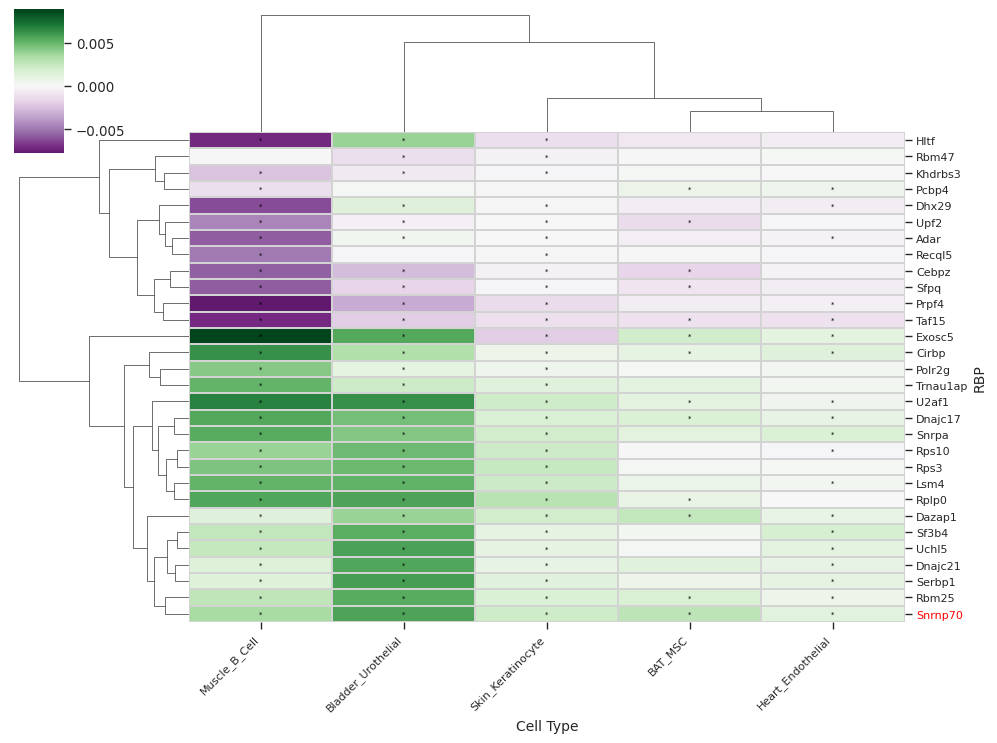

In [42]:
# Significant SPdiff hits
sig_hits = (
    all_res_df
    .query("path == 'Indirect' and sig=='Yes'")
    .copy()
)

cell_types_keep = ['Bladder_Urothelial', 'BAT_MSC', 'Muscle_B_Cell', 'Skin_Keratinocyte', 'Heart_Endothelial']
sig_hits = sig_hits[sig_hits["CellType"].isin(cell_types_keep)]

# Keep only these RBPs & cell types in the full results
rbps_keep = summary_df["RBP"].unique()
print(rbps_keep) 

subset_df = all_res_df[
    all_res_df["RBP"].str.upper().isin([r.upper() for r in rbps_keep]) &
    all_res_df["CellType"].isin(cell_types_keep) &
    (all_res_df["path"] == "Indirect")
].copy()

subset_df.reset_index(drop=True)

# Coef chosen based on max absolute value (so if multiple SPs are significant, choose the one with the highest effect size)
idx = subset_df.groupby(['RBP', 'CellType'])['coef'].transform(lambda x: x.abs() == x.abs().max())
subset_max = subset_df[idx].copy()

# Handle rare ties by dropping duplicates
subset_max = subset_max.drop_duplicates(subset=['RBP', 'CellType'])

# Pivot to RBP × CellType matrix (effect size or coef)
heatmap_df = subset_max.pivot(index="RBP", columns="CellType", values="coef").fillna(0)
print(f"The number of RBPs is {heatmap_df.shape[0]} and the number of cell types is {heatmap_df.shape[1]}")

# Choose value column
value_col = "coef" if "coef" in subset_max.columns else "effect_size"

# Collapse to one row per (RBP, CellType): take the row with the smallest FDR
pair_df = (
    subset_max.sort_values("pval_fdr")
             .drop_duplicates(["RBP", "CellType"])
)

# Values for heatmap
heatmap_df = (
    pair_df.pivot(index="RBP", columns="CellType", values=value_col)
           .fillna(0)
)

# Significance mask (FDR<0.05)
sig_mask = (
    (pair_df.assign(sig=lambda d: d["pval_fdr"] < 0.05))
    .pivot(index="RBP", columns="CellType", values="sig")
    .fillna(False)
)

# Ensure same index/columns in both
sig_mask = sig_mask.reindex(index=heatmap_df.index, columns=heatmap_df.columns, fill_value=False)

# --- 0) Reformat gene names to mouse style ---
heatmap_df.index = [name.capitalize() for name in heatmap_df.index]
sig_mask.index   = [name.capitalize() for name in sig_mask.index]

# --- 3) Plot with row_colors ---
figsize = (10, 8)
g = sns.clustermap(
    data=heatmap_df,
    cmap="PRGn",
    center=0,
    row_cluster=True,
    col_cluster=True,
    linewidths=0.15,
    linecolor="lightgray",
    xticklabels=True,
    yticklabels=True,
    figsize=figsize
)

# Axis labels
g.ax_heatmap.set_xlabel("Cell Type", fontsize=10)
g.ax_heatmap.set_ylabel("RBP", fontsize=10)

# Rotate/align x labels cleanly
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_horizontalalignment('right')
    lbl.set_fontsize(8)
    
# --- Color Snrnp70 y label red ---
# Find the tick labels for y-axis and set color for Snrnp70
for lbl in g.ax_heatmap.get_yticklabels():
    if lbl.get_text() == "Snrnp70":
        lbl.set_color("red")
    lbl.set_fontsize(8)
        
# Stars for FDR<0.05
row_order = [heatmap_df.index[i]   for i in g.dendrogram_row.reordered_ind]
col_order = [heatmap_df.columns[i] for i in g.dendrogram_col.reordered_ind]
for i, rbp in enumerate(row_order):
    for j, ct in enumerate(col_order):
        if sig_mask.loc[rbp, ct]:
            g.ax_heatmap.text(j + 0.5, i + 0.5, "*",
                              ha="center", va="center",
                              fontsize=5, color="black", clip_on=True)

# Legend for the row color strip
from matplotlib.patches import Patch

# --- 4) Save figure ---
plt.savefig(f"{output_dir}/RBP_SPdiff_mediation.pdf", bbox_inches='tight')
print(f"RBP_SPdiff_mediation.pdf saved to {output_dir}/RBP_SPdiff_mediation.pdf")

plt.show()

In [43]:
ge_adata.layers["scVI_linear"] = ge_adata.obsm["X_normalized_scVI_linear"]

In [44]:
from scipy.stats import spearmanr

# --- Settings ---
focal_cell_type = "Bladder_Urothelial"
rbps_interest = ["SNRNP70"]  # You can add more if you want
important_factors = [1, 3]  # SP_1, SP_2, SP_4

# --- Filter significant junction markers (all, no top-N) ---
filtered_df = sj_markers_df.loc[
    (sj_markers_df["factor_idx"].isin(important_factors)) &
    (sj_markers_df["significant"]) &
    (sj_markers_df["effect_size"] > 0.25)
].copy()

# All junction_id_index by factor
sp2_junc_idx = filtered_df.query("factor_idx == 1")["junction_id_index"].tolist()
sp4_junc_idx = filtered_df.query("factor_idx == 3")["junction_id_index"].tolist()

# Overlap check
overlap = set(sp2_junc_idx) & set(sp4_junc_idx)
print(f"Overlap count: {len(overlap)}")

# Remove overlapping junctions 
sp2_junc_idx = [i for i in sp2_junc_idx if i not in overlap]
sp4_junc_idx = [i for i in sp4_junc_idx if i not in overlap]

# Map junction_id_index -> .var position
var_lookup = dict(zip(splice_adata.var["junction_id_index"].values,
                      np.arange(splice_adata.n_vars)))

# Union positional indices
junc_union_idx = sorted(set(sp2_junc_idx) | set(sp4_junc_idx))
pos_idx = [var_lookup[i] for i in junc_union_idx if i in var_lookup]
junc_ids = splice_adata.var.iloc[pos_idx]["junction_id"].tolist()

# Program mapping
sp2_id_set = set(splice_adata.var.iloc[[var_lookup[i] for i in sp2_junc_idx if i in var_lookup]]["junction_id"])
sp4_id_set = set(splice_adata.var.iloc[[var_lookup[i] for i in sp4_junc_idx if i in var_lookup]]["junction_id"])

def program_of(jid):
    in2 = jid in sp2_id_set
    in3 = jid in sp4_id_set
    if in2 and in3: return "SP2+SP4"
    if in2: return "SP2"
    if in3: return "SP4"
    return "NA"

program_map = {jid: program_of(jid) for jid in junc_ids}

# --- Subset focal cell type ---
ct_cells = splice_adata.obs_names[splice_adata.obs["tissue_celltype"] == focal_cell_type]

# Extract PSI matrix
psi = pd.DataFrame(
    splice_adata.layers["denoised_PSI"][splice_adata.obs_names.isin(ct_cells), :][:, pos_idx],
    index=ct_cells,
    columns=junc_ids
)

# ### NEW: Extract Age Vector ###
# Ensure age is numeric. If it's a string like "3m", convert it first.
age_vals = splice_adata.obs.loc[ct_cells, "age_numeric"].values 

# --- Correlation analysis ---
results = []

# ### NEW: Pre-calculate Age Correlations once (efficient) ###
# This avoids re-calculating age correlation for every RBP loop
age_corrs = {}
print("Calculating Age vs PSI correlations...")
for jid in psi.columns:
    rho_age, p_age = spearmanr(age_vals, psi[jid].values)
    age_corrs[jid] = rho_age

for rbp in rbps_interest:
    rbp_expr = np.asarray(ge_adata[ct_cells, rbp].layers["scVI_linear"]).ravel()
    
    # Check detection
    if (rbp_expr > 0).mean() < 0.05:
        print(f"Skipping {rbp}: <5% detection in {focal_cell_type}")
        continue

    print(f"Calculating {rbp} correlations...")
    for jid in psi.columns:
        rho, p = spearmanr(rbp_expr, psi[jid].values)
        
        results.append({
            "CellType": focal_cell_type,
            "RBP": rbp,
            "junction_id": jid,
            "Program": program_map.get(jid, "NA"),
            "rho": rho,         # Correlation with RBP
            "pval": p,
            "age_rho": age_corrs[jid]  # Correlation with Age (Added here)
        })

corr_df = pd.DataFrame(results)
print(f"Correlations: {corr_df.shape[0]} RBP–junction pairs")

# --- Summarize ---
summary = (
    corr_df
    .groupby(["RBP", "Program"])["rho"]
    .agg(["median", "mean", "count"])
    .reset_index()
    .sort_values(["RBP", "Program"])
)
print(summary)

Overlap count: 11274
Calculating Age vs PSI correlations...
Calculating SNRNP70 correlations...
Correlations: 8169 RBP–junction pairs
       RBP Program    median     mean  count
0  SNRNP70     SP2  0.586589  0.54614   4813
1  SNRNP70     SP4 -0.479479 -0.41893   3356


Program
SP2    4813
SP4    3356
Name: count, dtype: int64
Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/SNRNP70_vs_Age_scatter.pdf


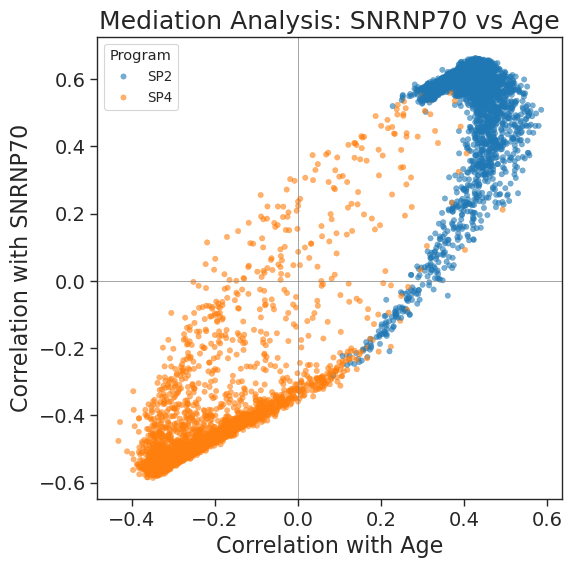

In [45]:
import os

plt.figure(figsize=(6, 6))

# Show all data 
plot_data = corr_df

print(plot_data["Program"].value_counts())

ax = sns.scatterplot(
    data=plot_data,
    x="age_rho", 
    y="rho", 
    hue="Program",
#    palette={"SP2": "#55a868", "SP4": "#8172b3"},
    s=15, alpha=0.6, edgecolor=None
)
plt.axhline(0, color="grey", lw=0.5)
plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("Correlation with Age", fontsize=16)
plt.ylabel("Correlation with SNRNP70", fontsize=16)
plt.title("Mediation Analysis: SNRNP70 vs Age", fontsize=18)

# Make tick font sizes bigger
ax.tick_params(axis='both', which='major', labelsize=14)
ax.tick_params(axis='both', which='minor', labelsize=12)

# Save as PDF to output_dir
output_path = os.path.join(output_dir, "SNRNP70_vs_Age_scatter.pdf")
plt.savefig(output_path, bbox_inches="tight")
print(f"Saved to {output_path}")
plt.show()

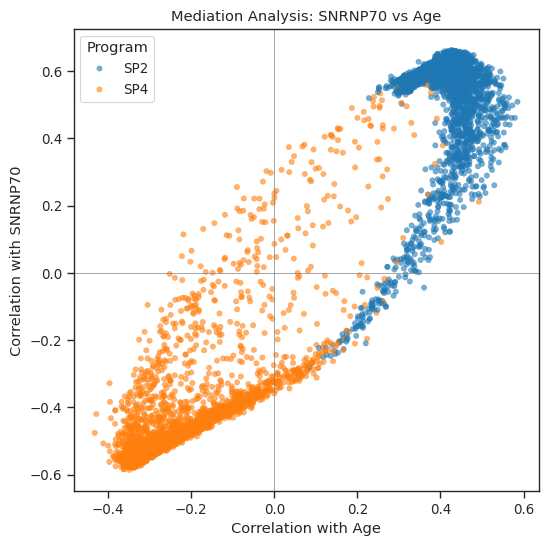

In [46]:
plt.figure(figsize=(6, 6))

# Filter for SP2 (Aging) and SP4 (Youth)
plot_data = corr_df[corr_df["Program"].isin(["SP2", "SP4"])]

sns.scatterplot(
    data=plot_data,
    x="age_rho", 
    y="rho", 
    hue="Program",
#    palette={"SP2": "#55a868", "SP4": "#8172b3"},
    s=15, alpha=0.6, edgecolor=None
)
plt.axhline(0, color="grey", lw=0.5); plt.axvline(0, color="grey", lw=0.5)
plt.xlabel("Correlation with Age"); plt.ylabel("Correlation with SNRNP70")
plt.title("Mediation Analysis: SNRNP70 vs Age")
plt.show()

In [47]:
# Calculate correlation between "Age Effect" and "SNRNP70 Effect"
from scipy.stats import pearsonr

# Filter for the pure programs only
clean_data = corr_df[corr_df["Program"].isin(["SP2", "SP4"])]

# Correlation of correlations
r_val, p_val = pearsonr(clean_data["age_rho"], clean_data["rho"])

print(f"Global Mechanism Concordance: R = {r_val:.2f}")

Global Mechanism Concordance: R = 0.96


In [48]:
# find strongest effect junction in SP4 
sp4_strongest = corr_df[corr_df["Program"] == "SP4"].sort_values("rho", ascending=True).iloc[0:10]
print(sp4_strongest)

# find strongest effect junction in SP2 
sp2_strongest = corr_df[corr_df["Program"] == "SP2"].sort_values("age_rho", ascending=False).iloc[0:5]
print(sp2_strongest)


                CellType      RBP                  junction_id Program  \
6165  Bladder_Urothelial  SNRNP70     chr6_34709697_34741788_+     SP4   
155   Bladder_Urothelial  SNRNP70    chr10_39526930_39529436_+     SP4   
6360  Bladder_Urothelial  SNRNP70     chr6_99016665_99028163_-     SP4   
591   Bladder_Urothelial  SNRNP70  chr11_120725896_120726087_-     SP4   
5924  Bladder_Urothelial  SNRNP70     chr5_88639078_88640588_+     SP4   
4910  Bladder_Urothelial  SNRNP70     chr3_89745601_89745819_+     SP4   
2674  Bladder_Urothelial  SNRNP70    chr17_35142384_35142726_+     SP4   
1193  Bladder_Urothelial  SNRNP70    chr12_59129896_59136063_+     SP4   
1367  Bladder_Urothelial  SNRNP70    chr13_13359423_13361297_-     SP4   
5241  Bladder_Urothelial  SNRNP70   chr4_149638395_149641657_+     SP4   

           rho           pval   age_rho  
6165 -0.586160  9.079796e-142 -0.349263  
155  -0.584600  7.589660e-141 -0.363065  
6360 -0.584155  1.388696e-140 -0.362009  
591  -0.580563  1

In [49]:
corr_df

,CellType,RBP,junction_id,Program,rho,pval,age_rho
0,Bladder_Urothelial,SNRNP70,chr10_100080130_100087346_+,SP2,0.578725,2.042145e-137,0.338243
1,Bladder_Urothelial,SNRNP70,chr10_100478022_100487161_-,SP2,0.573658,1.630613e-134,0.463008
2,Bladder_Urothelial,SNRNP70,chr10_105271580_105303593_-,SP2,0.643652,1.341831e-179,0.458757
3,Bladder_Urothelial,SNRNP70,chr10_106470591_106474631_+,SP4,-0.414073,2.115501e-64,-0.105134
4,Bladder_Urothelial,SNRNP70,chr10_106557299_106743486_+,SP4,-0.521076,3.531330e-107,-0.276878
...,...,...,...,...,...,...,...
8164,Bladder_Urothelial,SNRNP70,chrX_99071498_99072433_+,SP2,0.615481,4.402129e-160,0.442491
8165,Bladder_Urothelial,SNRNP70,chrY_1099752_1102764_-,SP2,0.618735,3.093039e-162,0.392106
8166,Bladder_Urothelial,SNRNP70,chrY_1199513_1224496_-,SP2,0.615015,8.905924e-160,0.414863
8167,Bladder_Urothelial,SNRNP70,chrY_898627_899427_+,SP2,0.589892,5.374454e-144,0.369574


In [50]:
sp4_strongest

,CellType,RBP,junction_id,Program,rho,pval,age_rho
6165,Bladder_Urothelial,SNRNP70,chr6_34709697_34741788_+,SP4,-0.586160,9.079796e-142,-0.349263
155,Bladder_Urothelial,SNRNP70,chr10_39526930_39529436_+,SP4,-0.584600,7.589660e-141,-0.363065
6360,Bladder_Urothelial,SNRNP70,chr6_99016665_99028163_-,SP4,-0.584155,1.388696e-140,-0.362009
591,Bladder_Urothelial,SNRNP70,chr11_120725896_120726087_-,SP4,-0.580563,1.755535e-138,-0.338276
5924,Bladder_Urothelial,SNRNP70,chr5_88639078_88640588_+,SP4,-0.579469,7.575708e-138,-0.343714
4910,Bladder_Urothelial,SNRNP70,chr3_89745601_89745819_+,SP4,-0.579127,1.194527e-137,-0.349126
2674,Bladder_Urothelial,SNRNP70,chr17_35142384_35142726_+,SP4,-0.578883,1.652837e-137,-0.338530
1193,Bladder_Urothelial,SNRNP70,chr12_59129896_59136063_+,SP4,-0.577794,7.029993e-137,-0.344916
1367,Bladder_Urothelial,SNRNP70,chr13_13359423_13361297_-,SP4,-0.577601,9.077512e-137,-0.350851
5241,Bladder_Urothelial,SNRNP70,chr4_149638395_149641657_+,SP4,-0.577273,1.401643e-136,-0.332891


In [51]:
def plot_psi_by_age_violin(splice_adata, junction_idx, OUTPUT_DIR=None, figsize=(4, 4)):
    """
    Create a violin plot showing denoised PSI values by age for a single junction
    """
        
    # Get denoised PSI data and age
    junction_psi = splice_adata.layers["denoised_PSI"][:, junction_idx]  # All cells for this junction
    ages = splice_adata.obs["age_numeric"].values
    junction_id = splice_adata.var["junction_id"].values[junction_idx]

    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'PSI': junction_psi,
        'Age': ages
    })
    
    # Remove any NaN values
    plot_df = plot_df.dropna()
    
    # Create the plot
    plt.figure(figsize=figsize)
    
    # Create violin plot with age as continuous variable
    sns.violinplot(data=plot_df, x='Age', y='PSI', 
                  color='#1976d2', alpha=0.7)
    
    # Customize plot
    title = f'Junction {junction_id}'
    plt.title(title, fontsize=11, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('Denoised Junction \nUsage Ratio', fontsize=11, fontweight='bold')

    # Increase tick font size 
    plt.tick_params(axis='both', which='major', labelsize=12)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    plt.gca().set_axisbelow(True)
    
    plt.tight_layout()
    if OUTPUT_DIR:
        plt.savefig(f"{OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf", dpi=300, bbox_inches='tight')
        print(f"Plot saved to {OUTPUT_DIR}/psi_by_age_violin_{junction_id}.pdf")
    plt.show()

In [52]:
splice_adata.var[splice_adata.var["junction_id"] == "chr10_39526930_39529436_+"]["junction_id_index"]

1619    1250
Name: junction_id_index, dtype: int64

In [53]:
splice_adata.var[splice_adata.var["junction_id_index"] == 1250]["event_id"]

1619    ENSMUSG00000019843.14_atse_3
Name: event_id, dtype: category
Categories (25305, object): ['ENSMUSG00000000001.4_atse_1', 'ENSMUSG00000000028.15_atse_1', 'ENSMUSG00000000028.15_atse_2', 'ENSMUSG00000000037.17_atse_1', ..., 'ENSMUSG00000117406.1_atse_2', 'ENSMUSG00000117679.1_atse_1', 'ENSMUSG00000117679.1_atse_2', 'ENSMUSG00000117679.1_atse_3']

In [54]:
splice_adata.var[splice_adata.var["junction_id_index"] == 1250]["junction_id"]

1619    chr10_39526930_39529436_+
Name: junction_id, dtype: object

In [55]:
splice_adata.var[splice_adata.var["event_id"] == "ENSMUSG00000019843.14_atse_3"]["junction_id_index"]

1619    1250
1620    1251
1621    1252
1622    1253
1623    1254
Name: junction_id_index, dtype: int64

In [56]:
juncs_sig = splice_adata.var[splice_adata.var["event_id"] == "ENSMUSG00000019843.14_atse_3"]["junction_id"]

In [57]:
sj_markers_df[sj_markers_df["junction_id"].isin(juncs_sig)]

,factor_idx,junction_idx,effect_size,abs_effect_size,effect_size_var,num_greater,prob_greater,prob_lessoreq,significant,delta,...,donor_usage,acceptor_usage,donor_total_reads,acceptor_total_reads,splice_motif_y,donor_seq,acceptor_seq,position_off_5_prime_y,position_off_3_prime_y,junction_annotation
1250,0,1250,-0.096025,0.096025,1.414810e-03,0.0,0.00,1.00,False,0.25,...,0.6462,1.0000,668295,431863,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1251,0,1251,0.018372,0.018372,4.500202e-04,0.0,0.00,1.00,False,0.25,...,0.3259,0.9971,668295,218435,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1252,0,1252,0.015474,0.015474,3.258472e-05,0.0,0.00,1.00,False,0.25,...,0.0269,0.0311,668295,577763,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1253,0,1253,-0.156456,0.156456,9.863552e-04,0.0,0.00,1.00,False,0.25,...,0.9984,0.6803,393669,577763,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1254,0,1254,0.038404,0.038404,4.552766e-04,0.0,0.00,1.00,False,0.25,...,0.2886,1.0000,577763,166762,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333188,19,1250,-0.013200,0.013200,6.048844e-03,1.0,0.01,0.99,False,0.25,...,0.6462,1.0000,668295,431863,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1333189,19,1251,-0.075859,0.075859,6.070930e-05,0.0,0.00,1.00,False,0.25,...,0.3259,0.9971,668295,218435,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1333190,19,1252,-0.001805,0.001805,1.624857e-07,0.0,0.00,1.00,False,0.25,...,0.0269,0.0311,668295,577763,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated
1333191,19,1253,0.010096,0.010096,5.632559e-03,1.0,0.01,0.99,False,0.25,...,0.9984,0.6803,393669,577763,GT-AG,GT,AG,0.0,1.0,Both_SS_annotated


In [58]:
corr_df[corr_df["junction_id"].isin(juncs_sig)]

,CellType,RBP,junction_id,Program,rho,pval,age_rho
155,Bladder_Urothelial,SNRNP70,chr10_39526930_39529436_+,SP4,-0.584600,7.589660e-141,-0.363065
156,Bladder_Urothelial,SNRNP70,chr10_39526930_39529918_+,SP2,0.574167,8.374011e-135,0.341447
157,Bladder_Urothelial,SNRNP70,chr10_39530074_39532015_+,SP2,0.579107,1.227971e-137,0.344064


In [59]:
splice_adata.var[splice_adata.var["event_id"] == "ENSMUSG00000019843.14_atse_3"][["junction_id_index", "junction_id", "event_id"]]

,junction_id_index,junction_id,event_id
1619,1250,chr10_39526930_39529436_+,ENSMUSG00000019843.14_atse_3
1620,1251,chr10_39526930_39529918_+,ENSMUSG00000019843.14_atse_3
1621,1252,chr10_39526930_39532015_+,ENSMUSG00000019843.14_atse_3
1622,1253,chr10_39529601_39532015_+,ENSMUSG00000019843.14_atse_3
1623,1254,chr10_39530074_39532015_+,ENSMUSG00000019843.14_atse_3


In [60]:
# check whether the rest of juncs_sig were differentially spliced

In [61]:
splice_adata.varm["psi_learned"][1250][1], splice_adata.varm["psi_learned"][1250][3]

(0.0007765885522909573, 0.6168828425014788)

In [62]:
splice_adata.varm["psi_learned"][1251][1], splice_adata.varm["psi_learned"][1251][3]

(0.5409189633715821, 0.021564662504884657)

In [63]:
splice_adata.varm["psi_learned"][1254][1], splice_adata.varm["psi_learned"][1254][3]

(0.4047665638174219, 0.017730377633109584)

In [64]:
splice_adata.var[splice_adata.var["event_id"] == "ENSMUSG00000019843.14_atse_3"]["junction_id_index"].values

array([1250, 1251, 1252, 1253, 1254])

Learned PSI barplot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/learned_psi_barplot_junctionid.pdf


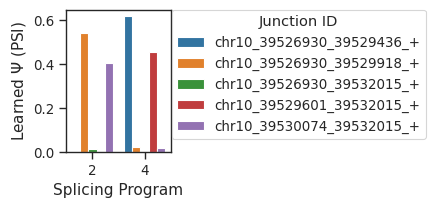

In [72]:
# Barplot for learned PSI program activities (for programs 2 and 4 [indices 1, 3]), 
# for all junctions in juncs_of_interest, using junction_id in color palette.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get both junction_id_index and junction_id for the event of interest
juncs_df = splice_adata.var[splice_adata.var["event_id"] == "ENSMUSG00000019843.14_atse_3"][["junction_id_index", "junction_id"]]
juncs_of_interest = juncs_df["junction_id_index"].values
junc_id_labels = juncs_df["junction_id"].values

program_indices = [1, 3]
program_names = [2, 4]  # 1-based for display

# Build DataFrame with MultiIndex columns: (junction_id_index, junction_id)
psi_dict = {}
for idx, ji in enumerate(juncs_of_interest):
    # Use the "junction_id" (string) as the key
    psi_dict[junc_id_labels[idx]] = splice_adata.varm["psi_learned"][ji][program_indices]

df = pd.DataFrame(psi_dict, index=program_names)
df.index.name = "Splicing Program"
df = df.reset_index()

# Melt for seaborn/bar plotting, using junction_id (the string, not the index) as the hue
col_order = ["Splicing Program"] + list(junc_id_labels)
df_melted = df.melt(id_vars="Splicing Program", value_vars=list(junc_id_labels),
                    var_name="Junction ID", value_name="Learned PSI")

# Make the plot less wide
plt.figure(figsize=(min(4.5, len(junc_id_labels)*0.8 + 1.5), 2.2))
sns.barplot(
    data=df_melted,
    x="Splicing Program",
    y="Learned PSI",
    hue="Junction ID",
    hue_order=list(junc_id_labels)
)

plt.xlabel("Splicing Program", fontsize=11)
plt.ylabel("Learned $\Psi$ (PSI)", fontsize=11)
plt.legend(title="Junction ID", bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.savefig(f"{output_dir}/learned_psi_barplot_junctionid.pdf", dpi=300, bbox_inches='tight')
print(f"Learned PSI barplot saved to {output_dir}/learned_psi_barplot_junctionid.pdf")
plt.show()

In [66]:
#array([1250, 1251, 1252, 1253, 1254])

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr10_39526930_39529436_+.pdf


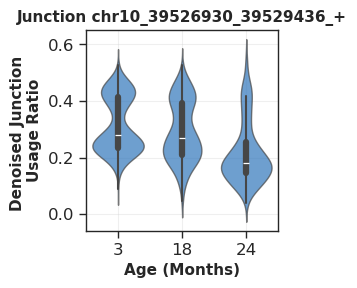

In [67]:
plot_psi_by_age_violin(splice_adata[splice_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=1250, OUTPUT_DIR=output_dir, figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr10_39526930_39529918_+.pdf


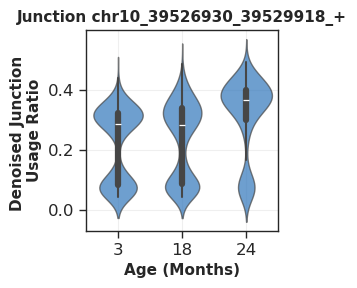

In [68]:
plot_psi_by_age_violin(splice_adata[splice_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=1251, OUTPUT_DIR=output_dir, figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr10_39526930_39532015_+.pdf


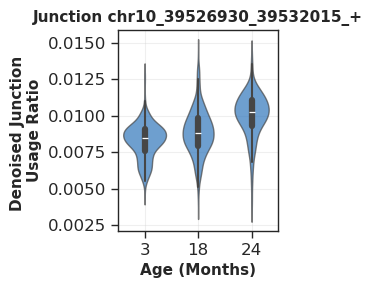

In [69]:
plot_psi_by_age_violin(splice_adata[splice_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=1252, OUTPUT_DIR=output_dir, figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr10_39529601_39532015_+.pdf


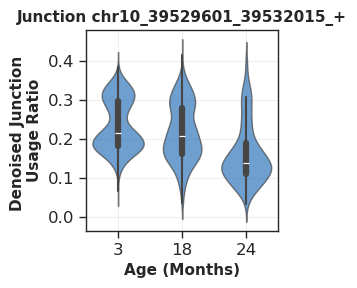

In [70]:
plot_psi_by_age_violin(splice_adata[splice_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=1253, OUTPUT_DIR=output_dir, figsize=(3, 3))

Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/psi_by_age_violin_chr10_39530074_39532015_+.pdf


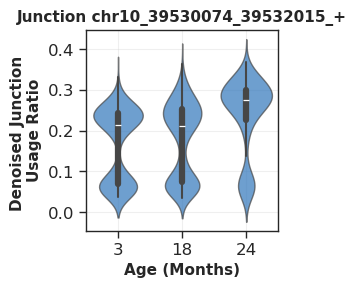

In [71]:
plot_psi_by_age_violin(splice_adata[splice_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], junction_idx=1254, OUTPUT_DIR=output_dir, figsize=(3, 3))

In [73]:
splice_adata, ge_adata

(AnnData object with n_obs × n_vars = 142315 × 70102
     obs: 'cell_id_index', 'age', 'donor_id', 'sex', 'subtissue', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'age_numeric', 'age_group', 'cell_ontology_class', 'broad_cell_type', 'tissue', 'tissue_celltype', 'dataset', 'total_counts', 'GAG_score', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20', 'perplexity'
     var: 'index', 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_id_index', 'n_cells_detected', 'confidence', 'aging_gene', 'aging_lifespan_effect', 'aging_longevity_in

In [80]:
# Plot gene expression for given gene across age 
def plot_gene_expression_by_age(adata, gene_name, layer="scVI_normalized", OUTPUT_DIR=None, figsize=(5, 5)):
    """
    Create a violin plot showing normalized gene expression by age,
    with median value for each age group reported.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 1. Check if gene exists in the object
    if gene_name not in adata.var_names:
        # Fallback check if gene_name is in a column called 'gene_name' instead of index
        if 'gene_name' in adata.var.columns and gene_name in adata.var['gene_name'].values:
            gene_idx = np.where(adata.var['gene_name'] == gene_name)[0][0]
        else:
            print(f"Error: {gene_name} not found in adata.")
            return
    else:
        gene_idx = adata.var_names.get_loc(gene_name)

    # 2. Extract expression data (handling sparse matrices if necessary)
    if layer in adata.layers:
        expression_values = adata.layers[layer][:, gene_idx]
    else:
        expression_values = adata.X[:, gene_idx]
        
    # Ensure it's a dense array for plotting
    if hasattr(expression_values, "toarray"):
        expression_values = expression_values.toarray().flatten()
    else:
        expression_values = expression_values.flatten()

    # 3. Create dataframe for plotting
    plot_df = pd.DataFrame({
        'Expression': expression_values,
        'Age': adata.obs['age_numeric'].values
    }).dropna()

    # 3b. Compute and print median expression for each age group
    # Group by Age and calculate median
    age_medians = plot_df.groupby("Age")["Expression"].median()
    print(f"Median {layer} expression for {gene_name} at each age:")
    for age, median_value in age_medians.items():
        print(f"  Age {age}: {median_value:.4f}")

    # 4. Create the plot
    plt.figure(figsize=figsize)
    
    # Use violin plot, with Age as categorical if many unique values
    sns.violinplot(
        data=plot_df, 
        x='Age', 
        y='Expression', 
        palette="viridis", # Sequential palette for age
        inner="quartile",
        linewidth=1.5
    )
    
    # Annotate each violin with the median value (as a point)
    for i, age in enumerate(sorted(plot_df["Age"].unique())):
        median_y = age_medians.loc[age]
        plt.scatter(i, median_y, color='red', zorder=10, label='Median' if i==0 else "", s=32)
    
    # 5. Customize Aesthetics
    plt.title(f'Expression of {gene_name}', fontsize=12, fontweight='bold')
    plt.xlabel('Age (Months)', fontsize=11, fontweight='bold')
    plt.ylabel('scVI Norm Exp', fontsize=11, fontweight='bold')

    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.grid(True, axis='y', alpha=0.3)
    plt.gca().set_axisbelow(True)
    # Show a legend for the red medians dot, but only once
    handles, labels = plt.gca().get_legend_handles_labels()
    if 'Median' not in labels:
        plt.scatter([], [], color='red', label='Median')
    plt.legend(loc='best', frameon=False, fontsize=9)
    
    plt.tight_layout()

    # 6. Save and Show
    if OUTPUT_DIR:
        filename = f"{OUTPUT_DIR}/expression_age_{gene_name}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {filename}")
        
    plt.show()

Median scVI_normalized expression for FYN at each age:
  Age 3: 0.0000
  Age 18: 0.0000
  Age 24: 0.0000
Plot saved to /gpfs/commons/home/kisaev/Leaflet-analysis/LeafletFA_Submission2025/Mouse_Splicing_Foundation/Figures/FIGURE4/figures/expression_age_FYN.pdf


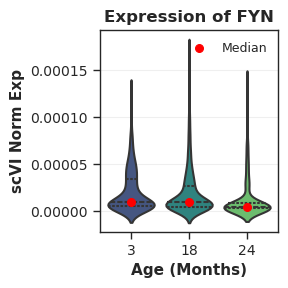

In [81]:
plot_gene_expression_by_age(ge_adata[ge_adata.obs["tissue_celltype"] == "Bladder_Urothelial"], gene_name="FYN", OUTPUT_DIR=output_dir, figsize=(3, 3))